
# Explainability visualization for **Multi-Relational Graph Attention KAN**

Notebook này được rút gọn thành đúng **3 tầng giải thích**:

1. **Relation-level**: relation nào quan trọng với từng class?
2. **Node/Subgraph-level**: graph nào, node nào là bằng chứng chính, và node nào được dự đoán là attack?
3. **Decision-level (KAN head)**: KAN head biến graph embedding thành quyết định như thế nào?

Mục tiêu là tạo ra đúng **3 hình/biểu đồ** dễ hiểu, bám sát narrative của paper:

> **relation → evidence → decision**


In [18]:

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

if '../' not in sys.path:
    sys.path.append('../')
print(sys.path)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
['/home/hieutt/MRGA-KAN', '/home/hieutt/MRGA-KAN/notebooks', '/home/hieutt/miniconda3/envs/torchtf/lib/python39.zip', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/lib-dynload', '', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/site-packages', '../']


In [19]:

from pathlib import Path
import sys

# =========================
# CHỈNH 4 BIẾN NÀY
# =========================
PROJECT_ROOT = Path('..').resolve()
GRAPH_FOLDER = PROJECT_ROOT / 'data/2017-subaru-forester/graphs_subsample_node_classification_v2'
CKPT_PATH = PROJECT_ROOT / 'save/graph_attention_ffn_kan_multitask_turning/graph_attention_ffn_kan_multitask_turning_best_joint.pth'
DEVICE = 'cpu'   # giữ CPU để visualize ổn định

# =========================
# lựa chọn dữ liệu / graph
# =========================
SPLIT = 'test'
NORMAL_LABEL = 'normal'      # nếu không khớp, notebook sẽ tự dò lại
ATTACK_LABEL = None          # ví dụ: 'combined'; None = tự lấy attack đầu tiên khác normal
NORMAL_OCCURRENCE = 0
ATTACK_OCCURRENCE = 0

# =========================
# Section 1: relation-level heatmap
# =========================
MAX_GRAPHS_PER_CLASS = 100    # giảm nếu muốn chạy nhanh hơn
ONLY_CORRECT = True          # chỉ dùng graph model dự đoán đúng để tính relation importance
RELATION_SCORE = 'true_logit_drop'   # hoặc 'pred_prob_drop'

# =========================
# Section 2: node/subgraph-level
# =========================
TOP_K_NODE_LABELS = 8
PLOT_RELATION_FILTER = ('temporal',)  # có thể đổi thành None để vẽ tất cả relation

# =========================
# Section 3: KAN head decision-level
# =========================
KAN_ANALYSIS_GRAPH = 'attack'   # 'attack' hoặc 'normal'
TOP_K_KAN_DIMS = 15
KAN_BG_MAX_SAMPLES = 80         # số graph dùng để tạo histogram embedding dim
KAN_BG_SAME_LABEL_ONLY = True   # histogram chỉ lấy graph cùng label với graph đang phân tích

MODEL_MODULE = 'networks.graph_attention_ffn_kan_multitask_updated'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('GRAPH_FOLDER =', GRAPH_FOLDER)
print('CKPT_PATH    =', CKPT_PATH)
print('DEVICE       =', DEVICE)
print('MODEL_MODULE =', MODEL_MODULE)


PROJECT_ROOT = /home/hieutt/MRGA-KAN
GRAPH_FOLDER = /home/hieutt/MRGA-KAN/data/2017-subaru-forester/graphs_subsample_node_classification_v2
CKPT_PATH    = /home/hieutt/MRGA-KAN/save/graph_attention_ffn_kan_multitask_turning/graph_attention_ffn_kan_multitask_turning_best_joint.pth
DEVICE       = cpu
MODEL_MODULE = networks.graph_attention_ffn_kan_multitask_updated


In [3]:

import os
import json
import math
import importlib
import inspect
from pathlib import Path
from typing import Dict, Any, Optional, List, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.data import Data
from matplotlib.lines import Line2D

plt.rcParams['figure.dpi'] = 120
sns.set_context('notebook')


## 1. Helper: load metadata, graphs, checkpoint, model

In [20]:

def load_table(base: Path) -> pd.DataFrame:
    pq = base.with_suffix('.parquet')
    csv = base.with_suffix('.csv')
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f'Cannot find {pq} or {csv}')


def normalize_label_name(x) -> str:
    return str(x).strip().lower()


def infer_label_mapping(graph_folder: Path) -> Dict[int, str]:
    mapping = {}
    for split in ['train', 'val', 'test']:
        try:
            df = load_table(graph_folder / f'graph_index_{split}')
            if 'y' in df.columns and 'window_label' in df.columns:
                pairs = df[['y', 'window_label']].drop_duplicates()
                for _, row in pairs.iterrows():
                    mapping[int(row['y'])] = str(row['window_label'])
        except Exception:
            continue
    return dict(sorted(mapping.items(), key=lambda kv: kv[0]))


def graph_dict_to_data(graph: dict) -> Data:
    """
    Convert one saved graph dictionary to PyG Data.

    Important for this notebook:
    - keep graph-level fields for graph classification/explainability;
    - also keep node_y/node_mask/node_is_attack because the checkpoint was
      trained with multitask node supervision.
    """
    data = Data(
        x=graph['x'].float(),
        edge_index=graph['edge_index'].long(),
        edge_attr=graph['edge_attr'].float(),
        edge_type=graph['edge_type'].long(),
        id_token=graph['id_index'].long() if 'id_index' in graph else graph['id_token'].long(),
        y=graph['y'].view(-1).long(),
    )

    # Optional message/window metadata
    if 'arbitration_id' in graph:
        data.arbitration_id = graph['arbitration_id'].long()
    if 'timestamp' in graph:
        data.timestamp = graph['timestamp'].float()
    if 'msg_idx_in_file' in graph:
        data.msg_idx_in_file = graph['msg_idx_in_file'].long()

    # Node-level labels used by the multitask checkpoint
    if 'node_y' in graph:
        data.node_y = graph['node_y'].long()
    if 'node_mask' in graph:
        data.node_mask = graph['node_mask'].bool()
    else:
        data.node_mask = torch.ones(data.x.size(0), dtype=torch.bool)
    if 'node_is_attack' in graph:
        data.node_is_attack = graph['node_is_attack'].long()

    data.graph_id = graph.get('graph_id', 'unknown_graph')
    data.window_label = graph.get('window_label', None)
    data.source_class = graph.get('source_class', None)
    data.meta = graph.get('meta', {})
    return data


def get_graph_label_name(raw_graph: dict, label_mapping: Dict[int, str]) -> str:
    if 'window_label' in raw_graph:
        return str(raw_graph['window_label'])
    y = int(raw_graph['y'].view(-1)[0].item())
    return label_mapping.get(y, f'class_{y}')


def load_graph_metadata(graph_folder: Path) -> Dict[str, Any]:
    meta_path = graph_folder / 'graph_metadata.json'
    if meta_path.exists():
        with open(meta_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {
        'relation_to_index': {'temporal': 0, 'same_id': 1, 'payload_sim': 2, 'timing_aff': 3},
        'index_to_relation': {'0': 'temporal', '1': 'same_id', '2': 'payload_sim', '3': 'timing_aff'},
    }


def infer_num_ids_from_shards(graph_folder: Path) -> int:
    max_id = -1
    for split in ['train', 'val', 'test']:
        split_dir = graph_folder / split
        if not split_dir.exists():
            continue
        for shard_path in sorted(split_dir.glob(f'graphs_{split}_shard*.pt')):
            shard_graphs = torch.load(shard_path, map_location='cpu', weights_only=False)
            for g in shard_graphs:
                if 'id_index' in g:
                    max_id = max(max_id, int(g['id_index'].max().item()))
    if max_id < 0:
        raise RuntimeError('Cannot infer num_ids from shards.')
    return max_id + 1


def iter_raw_graphs(graph_folder: Path, split: str):
    split_dir = graph_folder / split
    shard_paths = sorted(split_dir.glob(f'graphs_{split}_shard*.pt'))
    for shard_path in shard_paths:
        shard_graphs = torch.load(shard_path, map_location='cpu', weights_only=False)
        for raw_g in shard_graphs:
            yield raw_g


def get_split_label_counts(graph_folder: Path, split: str, label_mapping: Dict[int, str]) -> pd.DataFrame:
    df = load_table(graph_folder / f'graph_index_{split}').copy()

    if 'window_label' in df.columns:
        out = (
            df['window_label']
            .astype(str)
            .value_counts()
            .rename_axis('label_name')
            .reset_index(name='count')
        )
    elif 'y' in df.columns:
        out = (
            df['y']
            .astype(int)
            .value_counts()
            .rename_axis('label_id')
            .reset_index(name='count')
        )
        out['label_name'] = out['label_id'].map(label_mapping).fillna(out['label_id'].astype(str))
        out = out[['label_id', 'label_name', 'count']]
    else:
        raise ValueError('graph_index file has neither window_label nor y.')
    return out


def auto_find_normal_label(label_names: List[str]) -> Optional[str]:
    candidates = [str(x) for x in label_names]
    norm_map = {normalize_label_name(x): str(x) for x in candidates}
    for key in ['normal', 'benign', 'non_attack', 'non-attack', 'class_0', '0']:
        if key in norm_map:
            return norm_map[key]
    return None


def select_graph_by_label(
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    target_label: str,
    occurrence: int = 0,
) -> Tuple[dict, Data, str]:
    target_norm = normalize_label_name(target_label)
    seen = 0
    for raw_g in iter_raw_graphs(graph_folder, split):
        label_name = get_graph_label_name(raw_g, label_mapping)
        if normalize_label_name(label_name) == target_norm:
            if seen == occurrence:
                return raw_g, graph_dict_to_data(raw_g), label_name
            seen += 1
    raise ValueError(f'Cannot find label={target_label} occurrence={occurrence} in split={split}')


def select_first_attack_graph(
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    normal_label: str,
    occurrence: int = 0,
) -> Tuple[dict, Data, str]:
    normal_norm = normalize_label_name(normal_label)
    seen = 0
    for raw_g in iter_raw_graphs(graph_folder, split):
        label_name = get_graph_label_name(raw_g, label_mapping)
        if normalize_label_name(label_name) != normal_norm:
            if seen == occurrence:
                return raw_g, graph_dict_to_data(raw_g), label_name
            seen += 1
    raise ValueError(f'Cannot find attack graph in split={split}')


def import_model_class(module_name: str):
    mod = importlib.import_module(module_name)
    if not hasattr(mod, 'GraphAttentionKAN'):
        raise ImportError(f'Module {module_name} has no GraphAttentionKAN')
    return mod.GraphAttentionKAN


def build_model_from_checkpoint(
    ckpt_path: Path,
    sample_data: Data,
    graph_folder: Path,
    device: str = 'cpu',
    model_module: str = 'networks.graph_attention_ffn_kan_multitask_updated',
    strict_load: bool = True,
):
    """
    Build GraphAttentionKAN exactly as it was trained, then load checkpoint.

    The previous notebook version did not pass num_node_classes and
    node_head_from_layer, so the local model was created without node_head.
    That produced:
        Unexpected keys: node_head.*

    This version reconstructs the multitask model from checkpoint args.
    """
    GraphAttentionKAN = import_model_class(model_module)

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    args = ckpt.get('args', {})

    label_mapping = ckpt.get('label_mapping', infer_label_mapping(graph_folder))
    label_mapping = {int(k): str(v) for k, v in label_mapping.items()}
    label_mapping = dict(sorted(label_mapping.items(), key=lambda kv: kv[0]))
    num_graph_classes = len(label_mapping)

    # Node label mapping saved by the multitask trainer if available.
    # For node_target='node_y', num_node_classes should be the same as graph classes.
    node_label_mapping = ckpt.get('node_label_mapping', None)
    if isinstance(node_label_mapping, dict) and len(node_label_mapping) > 0:
        node_label_mapping = {int(k): str(v) for k, v in node_label_mapping.items()}
        num_node_classes = len(node_label_mapping)
    else:
        if bool(args.get('enable_node_task', True)):
            if args.get('node_target', 'node_y') == 'node_is_attack':
                num_node_classes = 2
                node_label_mapping = {0: 'normal', 1: 'attack'}
            else:
                num_node_classes = num_graph_classes
                node_label_mapping = label_mapping.copy()
        else:
            num_node_classes = None
            node_label_mapping = {}

    # Prefer checkpoint shape because it is the exact value used by the trained model.
    # The model defines nn.Embedding(num_ids + 1, id_emb_dim), so num_ids = rows - 1.
    state_dict = ckpt['model']
    if 'id_embedding.weight' in state_dict:
        num_ids = int(state_dict['id_embedding.weight'].shape[0]) - 1
    else:
        num_ids = infer_num_ids_from_shards(graph_folder)

    ctor_kwargs = dict(
        node_feat_dim=int(sample_data.x.size(1)),
        edge_attr_dim=int(sample_data.edge_attr.size(1)),
        num_classes=num_graph_classes,
        num_ids=num_ids,

        # Critical for multitask checkpoint loading
        num_node_classes=num_node_classes,
        node_head_from_layer=args.get('node_head_from_layer', -1),

        hidden_dim=args.get('hidden_dim', 128),
        num_layers=args.get('num_layers', 3),
        heads=args.get('heads', 2),
        id_emb_dim=args.get('id_emb_dim', 32),
        rel_emb_dim=args.get('rel_emb_dim', 8),
        num_relations=args.get('num_relations', 4),
        dropout=args.get('dropout', 0.2),
        ffn_ratio=args.get('ffn_ratio', 2.0),

        block_kan_grid_size=args.get('block_kan_grid_size', 3),
        block_kan_spline_order=args.get('block_kan_spline_order', 3),
        block_kan_scale_noise=args.get('block_kan_scale_noise', 0.1),
        block_kan_scale_base=args.get('block_kan_scale_base', 1.0),
        block_kan_scale_spline=args.get('block_kan_scale_spline', 1.0),

        kan_hidden=args.get('kan_hidden', 64),
        kan_grid_size=args.get('kan_grid_size', 3),
        kan_spline_order=args.get('kan_spline_order', 3),
        kan_scale_noise=args.get('kan_scale_noise', 0.1),
        kan_scale_base=args.get('kan_scale_base', 1.0),
        kan_scale_spline=args.get('kan_scale_spline', 1.0),
    )

    # Keep compatibility if local class has slightly different signature.
    sig = inspect.signature(GraphAttentionKAN.__init__)
    ctor_kwargs = {k: v for k, v in ctor_kwargs.items() if k in sig.parameters}

    model = GraphAttentionKAN(**ctor_kwargs)

    if strict_load:
        model.load_state_dict(state_dict, strict=True)
        missing, unexpected = [], []
    else:
        missing, unexpected = model.load_state_dict(state_dict, strict=False)

    model = model.to(device).eval()

    print('Loaded checkpoint:', ckpt_path)
    print('Missing keys   :', missing)
    print('Unexpected keys:', unexpected)
    print('num_classes    :', num_graph_classes)
    print('num_node_classes:', num_node_classes)
    print('node_target    :', args.get('node_target', 'node_y'))
    print('node_head_from_layer:', args.get('node_head_from_layer', -1))
    print('num_ids        :', num_ids)

    if len(missing) == 0 and len(unexpected) == 0:
        print('✅ Checkpoint loaded successfully. Model architecture matches the multitask checkpoint.')
    else:
        print('⚠️  CẢNH BÁO: model class local và checkpoint chưa khớp hoàn toàn.')

    return model, ckpt, label_mapping


def forward_logits(model, data: Data, device: str = 'cpu'):
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        logits = model(data)
    return logits.cpu()


def get_graph_embedding(model, data: Data, device: str = 'cpu') -> torch.Tensor:
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        try:
            out = model(data, return_graph_embedding=True)
            if isinstance(out, tuple) and len(out) == 2:
                _, g = out
                return g.detach().cpu()
        except TypeError:
            pass
        h = model.encode_nodes(data)
        batch = getattr(data, 'batch', None)
        if batch is None:
            batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        g = model.readout(h, batch)
        return g.detach().cpu()


def get_logits_from_embedding(model, g: torch.Tensor, device: str = 'cpu') -> torch.Tensor:
    model.eval()
    g = g.to(device)
    with torch.no_grad():
        logits = model.head(g)
    return logits.detach().cpu()


In [21]:

graph_meta = load_graph_metadata(GRAPH_FOLDER)
label_mapping = infer_label_mapping(GRAPH_FOLDER)
label_counts = get_split_label_counts(GRAPH_FOLDER, SPLIT, label_mapping)

display(label_counts)
print('label_mapping =', label_mapping)
print('relation mapping =', graph_meta.get('index_to_relation', {}))


,label_name,count
0,normal,13957
1,interval,6363
2,combined,4457
3,speed,1594
4,rpm,1328
5,systematic,987
6,fuzzing,864
7,gear,704
8,dos,667
9,standstill,617


label_mapping = {0: 'normal', 1: 'combined', 2: 'dos', 3: 'fuzzing', 4: 'gear', 5: 'interval', 6: 'rpm', 7: 'speed', 8: 'standstill', 9: 'systematic'}
relation mapping = {'0': 'temporal', '1': 'same_id', '2': 'payload_sim', '3': 'timing_aff'}


In [22]:

available_labels = label_counts['label_name'].astype(str).tolist()

resolved_normal_label = NORMAL_LABEL
if NORMAL_LABEL is None or normalize_label_name(NORMAL_LABEL) not in [normalize_label_name(x) for x in available_labels]:
    auto_label = auto_find_normal_label(available_labels)
    if auto_label is None:
        raise ValueError(f'Cannot resolve NORMAL_LABEL automatically. Available labels: {available_labels}')
    resolved_normal_label = auto_label

print('Resolved NORMAL_LABEL =', resolved_normal_label)

raw_normal, data_normal, normal_label_name = select_graph_by_label(
    GRAPH_FOLDER, SPLIT, label_mapping, resolved_normal_label, occurrence=NORMAL_OCCURRENCE
)

if ATTACK_LABEL is None:
    attack_candidates = [x for x in available_labels if normalize_label_name(x) != normalize_label_name(resolved_normal_label)]
    if len(attack_candidates) == 0:
        raise ValueError('No attack label found in this split.')
    resolved_attack_label = attack_candidates[ATTACK_OCCURRENCE]
else:
    resolved_attack_label = ATTACK_LABEL

raw_attack, data_attack, attack_label_name = select_graph_by_label(
    GRAPH_FOLDER, SPLIT, label_mapping, resolved_attack_label, occurrence=0
)

print('Normal graph:', data_normal.graph_id, '| label =', normal_label_name, '| nodes =', data_normal.x.size(0))
print('Attack graph:', data_attack.graph_id, '| label =', attack_label_name, '| nodes =', data_attack.x.size(0))

model, ckpt, ckpt_label_mapping = build_model_from_checkpoint(
    CKPT_PATH, data_normal, GRAPH_FOLDER, device=DEVICE, model_module=MODEL_MODULE
)


Resolved NORMAL_LABEL = normal
Normal graph: combined__00000384_00000448 | label = normal | nodes = 64
Attack graph: interval__00052416_00052480 | label = interval | nodes = 64
Loaded checkpoint: /home/hieutt/MRGA-KAN/save/graph_attention_ffn_kan_multitask_turning/graph_attention_ffn_kan_multitask_turning_best_joint.pth
Missing keys   : []
Unexpected keys: []
num_classes    : 10
num_node_classes: 10
node_target    : node_y
node_head_from_layer: -1
num_ids        : 1568
✅ Checkpoint loaded successfully. Model architecture matches the multitask checkpoint.



# Phần 1 — Relation-level explanation

**Mục tiêu**: relation nào thực sự quan trọng với từng class?

Ta dùng **relation ablation**:
- giữ nguyên graph
- lần lượt loại bỏ từng relation (`temporal`, `same_id`, `payload_sim`, `timing_aff`)
- đo mức giảm score của class đúng

Hình duy nhất ở phần này là **heatmap class × relation importance**.


In [25]:

DEFAULT_RELATION_TO_INDEX = {'temporal': 0, 'same_id': 1, 'payload_sim': 2, 'timing_aff': 3}
DEFAULT_INDEX_TO_RELATION = {v: k for k, v in DEFAULT_RELATION_TO_INDEX.items()}

def get_relation_mapping(graph_meta):
    idx2rel = graph_meta.get('index_to_relation', {})
    out = {}
    for k, v in idx2rel.items():
        try:
            out[int(k)] = v
        except Exception:
            pass
    if not out:
        out = DEFAULT_INDEX_TO_RELATION
    return out

INDEX_TO_RELATION = get_relation_mapping(graph_meta)
RELATION_TO_INDEX = {v: k for k, v in INDEX_TO_RELATION.items()}


def clone_data(data: Data) -> Data:
    out = Data()
    for k in data.keys():
        v = getattr(data, k)
        if torch.is_tensor(v):
            out[k] = v.clone()
        else:
            out[k] = v
    return out


def ablate_relation(data: Data, relation_idx: int) -> Data:
    out = clone_data(data)
    mask = out.edge_type != int(relation_idx)
    out.edge_index = out.edge_index[:, mask]
    out.edge_attr = out.edge_attr[mask]
    out.edge_type = out.edge_type[mask]
    return out


def score_from_logits(logits: torch.Tensor, target_idx: int, mode: str = 'true_logit_drop') -> float:
    if mode == 'true_logit_drop':
        return float(logits[0, target_idx].item())
    if mode == 'pred_prob_drop':
        prob = torch.softmax(logits, dim=1)
        return float(prob[0, target_idx].item())
    raise ValueError(f'Unknown mode: {mode}')


import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import Dict, Optional, List, Tuple
from collections import defaultdict
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader


def clean_data_for_relation_batch(data: Data) -> Data:
    """
    Keep only tensor attributes needed by the model.
    This avoids PyG batching errors caused by metadata/dict fields.
    """
    clean = Data()

    clean.x = data.x.float()
    clean.edge_index = data.edge_index.long()

    if hasattr(data, "edge_attr") and data.edge_attr is not None:
        clean.edge_attr = data.edge_attr.float()

    if hasattr(data, "edge_type") and data.edge_type is not None:
        clean.edge_type = data.edge_type.long()

    if hasattr(data, "id_token") and data.id_token is not None:
        clean.id_token = data.id_token.long()
    elif hasattr(data, "id_index") and data.id_index is not None:
        clean.id_token = data.id_index.long()

    clean.y = data.y.view(-1).long()

    return clean


def parse_graph_logits_from_output(output):
    """
    Support model outputs:
    - dict with graph_logits
    - tuple/list where output[0] is graph_logits
    - direct logits tensor
    """
    if isinstance(output, dict):
        return output.get("graph_logits", None)

    if isinstance(output, (tuple, list)):
        return output[0]

    return output


@torch.no_grad()
def forward_logits_batch(model, data_list: List[Data], device: str = "cpu") -> torch.Tensor:
    """
    Forward multiple graphs in one PyG batch.
    Returns graph logits with shape [B, num_classes].
    """
    model.eval()

    clean_list = [clean_data_for_relation_batch(d) for d in data_list]

    loader = DataLoader(
        clean_list,
        batch_size=len(clean_list),
        shuffle=False,
    )

    batch = next(iter(loader)).to(device)

    batch.x = batch.x.float()
    batch.edge_index = batch.edge_index.long()

    if hasattr(batch, "edge_attr"):
        batch.edge_attr = batch.edge_attr.float()

    if hasattr(batch, "edge_type"):
        batch.edge_type = batch.edge_type.long()

    if hasattr(batch, "id_token"):
        batch.id_token = batch.id_token.long()

    try:
        output = model(batch, return_node_logits=False)
    except TypeError:
        output = model(batch)

    logits = parse_graph_logits_from_output(output)

    if logits is None:
        raise RuntimeError("Model output does not contain graph_logits.")

    return logits.detach().cpu()


def aggregate_relation_records(
    records: List[dict],
    label_ids: List[int],
    label_names: List[str],
    rel_names: List[str],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Aggregate per-graph relation drops into class-wise mean matrix.
    """
    mat = np.full((len(label_ids), len(rel_names)), np.nan, dtype=np.float32)
    count_mat = np.zeros((len(label_ids), len(rel_names)), dtype=np.int32)

    by_class = defaultdict(list)
    for rec in records:
        by_class[int(rec["y"])].append(rec)

    for i, lid in enumerate(label_ids):
        class_records = by_class.get(int(lid), [])

        for j, rel_name in enumerate(rel_names):
            vals = [
                float(r["drops"][rel_name])
                for r in class_records
                if rel_name in r["drops"]
            ]

            if len(vals) > 0:
                mat[i, j] = float(np.mean(vals))
                count_mat[i, j] = len(vals)

    heat_df = pd.DataFrame(mat, index=label_names, columns=rel_names)
    count_df = pd.DataFrame(count_mat, index=label_names, columns=rel_names)

    return heat_df, count_df

def collect_relation_importance_matrix_v2(
    model,
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    relation_to_index: Dict[str, int],

    # Main option
    method: str = "full",   # "full" or "repeated"

    # Full-set option
    max_graphs_total: Optional[int] = None,

    # Repeated stratified sampling options
    samples_per_class: int = 100,
    n_repeats: int = 10,
    max_pool_per_class: Optional[int] = None,
    sample_with_replacement: bool = False,
    random_seed: int = 42,

    # Evaluation options
    only_correct: bool = True,
    score_mode: str = "true_logit_drop",
    device: str = "cpu",

    # Speed / logging
    print_every: int = 1000,
):
    """
    Compute relation importance by removing one relation type at inference time.

    Two modes:
    ---------
    method="full":
        Use all graphs in the selected split.
        This is the most reliable option if computation time allows.

    method="repeated":
        Precompute relation drops for a candidate pool, then perform repeated
        stratified sampling, e.g., 100 graphs/class x 10 repeats.
        This reduces sampling bias compared with one-time 100 graphs/class.

    Score drop:
    -----------
    drop = score(full graph) - score(graph without relation r)

    If drop > 0:
        removing relation r reduces score, so relation r is useful.

    If drop < 0:
        removing relation r slightly improves score for that class/sample.
    """

    method = method.lower().strip()
    assert method in {"full", "repeated"}, "method must be 'full' or 'repeated'"

    labels_sorted = sorted(label_mapping.items(), key=lambda kv: int(kv[0]))
    label_ids = [int(k) for k, _ in labels_sorted]
    label_names = [str(v) for _, v in labels_sorted]

    rel_names = list(relation_to_index.keys())

    model.eval()

    # Store per-graph results
    records = []
    per_class_counts_seen = {lid: 0 for lid in label_ids}
    per_class_counts_used = {lid: 0 for lid in label_ids}

    # For repeated mode, we can stop collecting pool after max_pool_per_class per class.
    pool_full_enough = False

    total_seen = 0
    total_used = 0

    for raw_g in iter_raw_graphs(graph_folder, split):
        total_seen += 1

        data = graph_dict_to_data(raw_g)
        y = int(data.y.view(-1)[0].item())

        if y not in per_class_counts_seen:
            continue

        per_class_counts_seen[y] += 1

        # In repeated mode, optionally limit the candidate pool per class
        if method == "repeated" and max_pool_per_class is not None:
            if per_class_counts_used[y] >= max_pool_per_class:
                # Check whether all classes already have enough pool samples
                if all(per_class_counts_used[lid] >= max_pool_per_class for lid in label_ids):
                    pool_full_enough = True
                    break
                continue

        # In full mode, optionally stop by total graph count
        if method == "full" and max_graphs_total is not None:
            if total_used >= max_graphs_total:
                break

        # ------------------------------------------------------------
        # Forward base graph + all relation-ablated graphs in one batch
        # ------------------------------------------------------------
        variant_graphs = [data]
        variant_rel_names = ["__base__"]

        for rel_name, rel_idx in relation_to_index.items():
            data_rel = ablate_relation(data, rel_idx)
            variant_graphs.append(data_rel)
            variant_rel_names.append(rel_name)

        try:
            logits_batch = forward_logits_batch(
                model=model,
                data_list=variant_graphs,
                device=device,
            )
        except Exception as e:
            print(f"Skip graph #{total_seen} due to forward error: {e}")
            continue

        base_logits = logits_batch[0:1]
        pred = int(base_logits.argmax(dim=1).item())

        if only_correct and pred != y:
            continue

        target_idx = y if score_mode == "true_logit_drop" else pred
        base_score = score_from_logits(base_logits, target_idx, mode=score_mode)

        drops = {}
        for k, rel_name in enumerate(variant_rel_names[1:], start=1):
            rel_logits = logits_batch[k:k + 1]
            rel_score = score_from_logits(rel_logits, target_idx, mode=score_mode)
            drops[rel_name] = float(base_score - rel_score)

        rec = {
            "y": y,
            "label": label_mapping[y],
            "pred": pred,
            "drops": drops,
        }

        records.append(rec)
        per_class_counts_used[y] += 1
        total_used += 1

        if print_every is not None and print_every > 0:
            if total_seen % print_every == 0:
                print(
                    f"[{split}] seen={total_seen}, used={total_used}, "
                    f"used_per_class={per_class_counts_used}"
                )

    if len(records) == 0:
        raise RuntimeError(
            "No valid records collected. Try only_correct=False or check model/data."
        )

    raw_records_df = pd.DataFrame([
        {
            "y": r["y"],
            "label": r["label"],
            "pred": r["pred"],
            **{f"drop_{rel}": r["drops"].get(rel, np.nan) for rel in rel_names}
        }
        for r in records
    ])

    # ============================================================
    # Method 1: Full test set / full selected split
    # ============================================================
    if method == "full":
        heat_df, count_df = aggregate_relation_records(
            records=records,
            label_ids=label_ids,
            label_names=label_names,
            rel_names=rel_names,
        )

        result = {
            "method": "full",
            "mean": heat_df,
            "std": None,
            "count": count_df,
            "records": raw_records_df,
            "per_class_counts_seen": per_class_counts_seen,
            "per_class_counts_used": per_class_counts_used,
            "num_records": len(records),
        }

        print("=" * 100)
        print("Relation importance collection finished")
        print("Method:", method)
        print("Total seen:", total_seen)
        print("Total used:", total_used)
        print("Per-class used:", per_class_counts_used)
        print("=" * 100)

        return result

    # ============================================================
    # Method 2: Repeated stratified sampling
    # ============================================================
    records_by_class = defaultdict(list)
    for rec in records:
        records_by_class[int(rec["y"])].append(rec)

    rng = np.random.default_rng(random_seed)

    repeat_mats = []
    repeat_count_mats = []
    repeat_records_info = []

    for rep in range(n_repeats):
        sampled_records = []
        rep_counts = {lid: 0 for lid in label_ids}

        for lid in label_ids:
            pool = records_by_class.get(int(lid), [])

            if len(pool) == 0:
                continue

            if sample_with_replacement:
                k = samples_per_class
                sampled_idx = rng.choice(len(pool), size=k, replace=True)
            else:
                k = min(samples_per_class, len(pool))
                sampled_idx = rng.choice(len(pool), size=k, replace=False)

            selected = [pool[int(i)] for i in sampled_idx]
            sampled_records.extend(selected)
            rep_counts[lid] = len(selected)

        heat_rep, count_rep = aggregate_relation_records(
            records=sampled_records,
            label_ids=label_ids,
            label_names=label_names,
            rel_names=rel_names,
        )

        repeat_mats.append(heat_rep.to_numpy(dtype=np.float32))
        repeat_count_mats.append(count_rep.to_numpy(dtype=np.float32))
        repeat_records_info.append(rep_counts)

    repeat_stack = np.stack(repeat_mats, axis=0)

    mean_mat = np.nanmean(repeat_stack, axis=0)

    if n_repeats > 1:
        std_mat = np.nanstd(repeat_stack, axis=0, ddof=1)
    else:
        std_mat = np.zeros_like(mean_mat)

    mean_df = pd.DataFrame(mean_mat, index=label_names, columns=rel_names)
    std_df = pd.DataFrame(std_mat, index=label_names, columns=rel_names)

    # Average number of samples used per class/relation over repeats
    count_stack = np.stack(repeat_count_mats, axis=0)
    count_mean_mat = np.nanmean(count_stack, axis=0)
    count_df = pd.DataFrame(count_mean_mat, index=label_names, columns=rel_names)

    result = {
        "method": "repeated",
        "mean": mean_df,
        "std": std_df,
        "count": count_df,
        "records": raw_records_df,
        "repeat_matrices": repeat_mats,
        "repeat_counts": repeat_records_info,
        "per_class_counts_seen": per_class_counts_seen,
        "per_class_counts_used": per_class_counts_used,
        "num_records": len(records),
        "samples_per_class": samples_per_class,
        "n_repeats": n_repeats,
    }

    print("=" * 100)
    print("Relation importance collection finished")
    print("Method:", method)
    print("Total seen:", total_seen)
    print("Total used in candidate pool:", total_used)
    print("Per-class pool size:", per_class_counts_used)
    print("Samples per class per repeat:", samples_per_class)
    print("Repeats:", n_repeats)
    print("=" * 100)

    return result

def plot_relation_heatmap(heat_df: pd.DataFrame, title: str = None, save_path: str = None):
    plt.rcParams.update({
        "axes.labelsize": 12,
        "font.size": 11,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.titlesize": 14,
        "pdf.fonttype": 42,  # Tránh lỗi Type 3 font khi nộp báo
        "ps.fonttype": 42
    })
    
    # Kích thước biểu đồ tiêu chuẩn
    fig, ax = plt.subplots(figsize=(8, 6))
    vmax = np.nanmax(np.abs(heat_df.values)) if np.isfinite(heat_df.values).any() else 1.0
    
    # Định dạng lại tên cột và hàng (viết hoa chữ cái đầu, thay '_' bằng dấu cách)
    display_df = heat_df.copy()
    display_df.index = [str(idx).replace('_', ' ').title() for idx in display_df.index]
    display_df.columns = [str(col).replace('_', ' ').title() for col in display_df.columns]

    sns.heatmap(
        display_df,
        annot=True,
        fmt='.2f',          # Rút gọn còn 2 chữ số thập phân cho đỡ rối mắt
        cmap='coolwarm',    # Bảng màu chuyên nghiệp hơn
        center=0,
        vmin=-vmax,
        vmax=vmax,
        linewidths=1,       # Viền dày 1px
        linecolor='white',  # Viền trắng để các ô vuông vắn, tách bạch
        cbar_kws={
            'label': 'Score Drop (Impact)', 
            'shrink': 0.85  # Thu ngắn thanh colorbar cho cân đối
        },
        ax=ax
    )
    
    # Tiêu đề (thường báo khoa học không để title trong hình mà để ở caption, 
    # nhưng tôi vẫn giữ lại nếu bạn cần)
    if title:
        plt.title(title, pad=15, fontweight='bold')
        
    plt.xlabel('Relation Type', fontweight='bold', labelpad=10)
    plt.ylabel('Class', fontweight='bold', labelpad=10)
    
    # Căn chỉnh lại nhãn trục X và Y để không bị cắt chữ
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # Lưu file chất lượng cao nếu có truyền đường dẫn
    if save_path is not None:
        import os
        from pathlib import Path

        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            format=save_path.suffix.replace(".", "")
        )

        print(f"[*] Saved high-res figure to: {save_path}")
        
    plt.show()
    
    # Reset lại rcParams về mặc định (tránh ảnh hưởng các plot sau nếu không muốn)
    plt.rcdefaults()


[test] seen=500, used=500, used_per_class={0: 500, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}
[test] seen=1000, used=1000, used_per_class={0: 829, 1: 171, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}
[test] seen=1500, used=1500, used_per_class={0: 829, 1: 671, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}
[test] seen=4500, used=1881, used_per_class={0: 881, 1: 1000, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}
[test] seen=8000, used=2373, used_per_class={0: 1000, 1: 1000, 2: 373, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}
[test] seen=10000, used=2883, used_per_class={0: 1000, 1: 1000, 2: 667, 3: 216, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}
[test] seen=11000, used=3443, used_per_class={0: 1000, 1: 1000, 2: 667, 3: 776, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}
[test] seen=12000, used=3667, used_per_class={0: 1000, 1: 1000, 2: 667, 3: 864, 4: 136, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}
[test] seen=12500, used=4038, used_per_class={0: 1000, 1: 1000, 2: 667, 3: 864, 4: 507, 5: 0, 6: 0, 7: 0

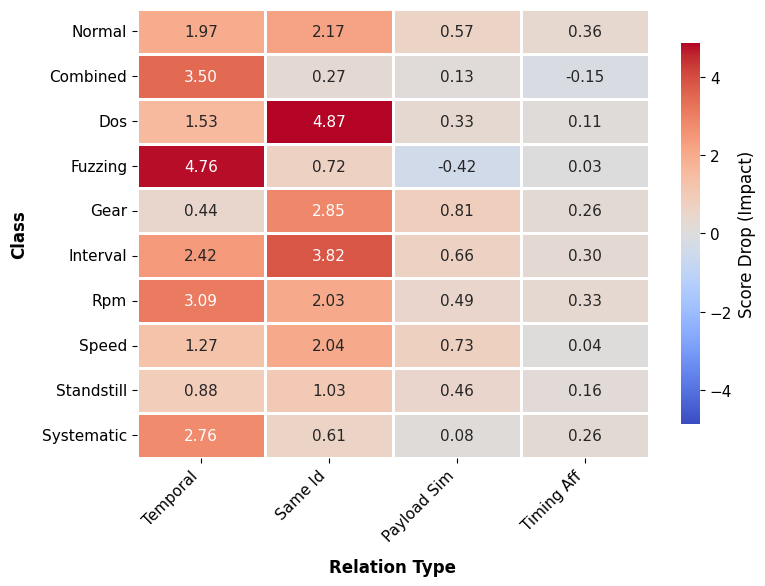

[*] Saved high-res figure to: ../figures/explainability/relation_heatmap_repeated.pdf


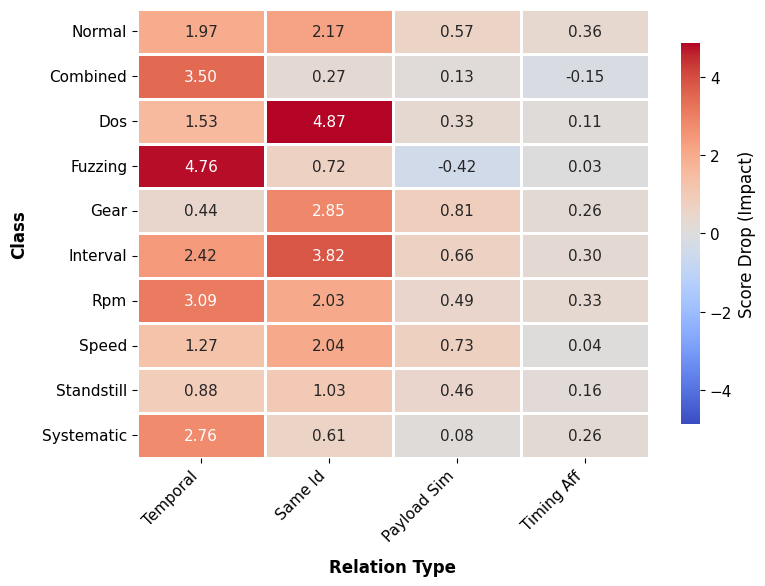

,temporal,same_id,payload_sim,timing_aff
normal,1.968137,2.173235,0.572863,0.358854
combined,3.499486,0.274475,0.128833,-0.153666
dos,1.531618,4.870018,0.329778,0.108591
fuzzing,4.757169,0.715965,-0.423284,0.029928
gear,0.438042,2.847807,0.810786,0.255790
interval,2.418701,3.816229,0.657708,0.301954
rpm,3.087815,2.025744,0.485175,0.329355
speed,1.269921,2.041254,0.729193,0.044582
standstill,0.884768,1.034057,0.463516,0.164817
systematic,2.755505,0.606090,0.078407,0.256621


,temporal,same_id,payload_sim,timing_aff
normal,100.0,100.0,100.0,100.0
combined,100.0,100.0,100.0,100.0
dos,100.0,100.0,100.0,100.0
fuzzing,100.0,100.0,100.0,100.0
gear,100.0,100.0,100.0,100.0
interval,100.0,100.0,100.0,100.0
rpm,100.0,100.0,100.0,100.0
speed,100.0,100.0,100.0,100.0
standstill,100.0,100.0,100.0,100.0
systematic,100.0,100.0,100.0,100.0


Standard deviation over repeated sampling:


,temporal,same_id,payload_sim,timing_aff
normal,0.086962,0.150079,0.075228,0.049526
combined,0.174580,0.058289,0.057622,0.036388
dos,0.129517,0.279627,0.075592,0.074660
fuzzing,0.155530,0.161241,0.041483,0.059491
gear,0.094187,0.141984,0.054645,0.051791
interval,0.089832,0.155189,0.057596,0.027539
rpm,0.212508,0.183979,0.051411,0.033005
speed,0.222267,0.135335,0.099664,0.049021
standstill,0.116980,0.159635,0.048812,0.057244
systematic,0.118464,0.114334,0.026444,0.056005


Graphs seen per class = {0: 13957, 1: 4457, 2: 667, 3: 864, 4: 704, 5: 6363, 6: 1328, 7: 1594, 8: 617, 9: 987}
Graphs used per class = {0: 1000, 1: 1000, 2: 667, 3: 864, 4: 704, 5: 1000, 6: 1000, 7: 1000, 8: 617, 9: 987}
Number of valid records = 8839


In [27]:
# ============================================================
# Relation-level sensitivity analysis using the new function
# ============================================================

# Choose one:
#   "full"     : evaluate on the full split/test set
#   "repeated" : repeated stratified sampling, e.g., 100 graphs/class × 10 repeats
RELATION_ANALYSIS_METHOD = "repeated"   # đổi thành "full" nếu muốn dùng toàn bộ test set

# For repeated sampling
SAMPLES_PER_CLASS = 100
N_REPEATS = 10

# If running too slowly, set this to 500 or 1000.
# If you want to collect all valid graphs into the pool, keep None.
MAX_POOL_PER_CLASS = 1000

# Recommended:
#   ONLY_CORRECT = True  -> relation sensitivity on correctly classified graphs
#   ONLY_CORRECT = False -> relation sensitivity on all evaluated graphs
ONLY_CORRECT = False

# Score mode:
#   "true_logit_drop" is usually suitable for explaining class-specific contribution
RELATION_SCORE = "true_logit_drop"


relation_result = collect_relation_importance_matrix_v2(
    model=model,
    graph_folder=GRAPH_FOLDER,
    split=SPLIT,
    label_mapping=ckpt_label_mapping,
    relation_to_index=RELATION_TO_INDEX,

    # Main option
    method=RELATION_ANALYSIS_METHOD,

    # Full-set option
    max_graphs_total=None,

    # Repeated sampling option
    samples_per_class=SAMPLES_PER_CLASS,
    n_repeats=N_REPEATS,
    max_pool_per_class=MAX_POOL_PER_CLASS,
    sample_with_replacement=False,
    random_seed=42,

    # Evaluation option
    only_correct=ONLY_CORRECT,
    score_mode=RELATION_SCORE,
    device=DEVICE,

    # Logging
    print_every=500,
)

# ============================================================
# Extract result matrices
# ============================================================

relation_heat_df = relation_result["mean"]
relation_count_df = relation_result["count"]
per_class_counts = relation_result["per_class_counts_used"]

# For repeated sampling, std is also available
if RELATION_ANALYSIS_METHOD == "repeated":
    relation_std_df = relation_result["std"]
else:
    relation_std_df = None

# ============================================================
# Save result tables
# ============================================================

out_dir = Path("../figures/explainability")
out_dir.mkdir(parents=True, exist_ok=True)

relation_heat_df.to_csv(out_dir / f"relation_importance_{RELATION_ANALYSIS_METHOD}_mean.csv")
relation_count_df.to_csv(out_dir / f"relation_importance_{RELATION_ANALYSIS_METHOD}_count.csv")
relation_result["records"].to_csv(
    out_dir / f"relation_importance_{RELATION_ANALYSIS_METHOD}_records.csv",
    index=False
)

if relation_std_df is not None:
    relation_std_df.to_csv(out_dir / f"relation_importance_{RELATION_ANALYSIS_METHOD}_std.csv")

# ============================================================
# Plot heatmap
# ============================================================

plot_relation_heatmap(
    relation_heat_df,
    title=None,
    save_path=out_dir / f"relation_heatmap_{RELATION_ANALYSIS_METHOD}.png"
)

# Nếu muốn lưu PDF vector cho paper
plot_relation_heatmap(
    relation_heat_df,
    title=None,
    save_path=out_dir / f"relation_heatmap_{RELATION_ANALYSIS_METHOD}.pdf"
)

display(relation_heat_df)
display(relation_count_df)

if relation_std_df is not None:
    print("Standard deviation over repeated sampling:")
    display(relation_std_df)

print("Graphs seen per class =", relation_result["per_class_counts_seen"])
print("Graphs used per class =", per_class_counts)
print("Number of valid records =", relation_result["num_records"])


# Phần 2 — Node/Subgraph-level explanation

**Mục tiêu**: graph nào, node nào là bằng chứng chính?

Ta dùng **node occlusion** trên đúng 2 graph case-study:
- 1 graph `normal`
- 1 graph `attack`

Với mỗi node, ta:
- che node đó (zero features và bỏ các cạnh incident)
- đo mức giảm score của class được dự đoán

Hình duy nhất ở phần này là **2 panel: normal vs attack**, node tô màu theo mức quan trọng.


In [9]:
from typing import Optional, List
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from torch_geometric.data import Data
import os

def mask_node_and_incident_edges(data: Data, node_idx: int) -> Data:
    out = clone_data(data)
    out.x[node_idx] = 0.0
    incident = (out.edge_index[0] == node_idx) | (out.edge_index[1] == node_idx)
    keep = ~incident
    out.edge_index = out.edge_index[:, keep]
    out.edge_attr = out.edge_attr[keep]
    out.edge_type = out.edge_type[keep]
    return out

def compute_node_occlusion_importance(model, data: Data, device: str = "cpu", target_mode: str = "pred"):
    logits = forward_logits(model, data, device=device)
    pred_idx = int(logits.argmax(dim=1).item())
    true_idx = int(data.y.view(-1)[0].item())
    target_idx = pred_idx if target_mode == "pred" else true_idx
    base_score = float(logits[0, target_idx].item())

    scores = []
    for i in range(data.x.size(0)):
        data_i = mask_node_and_incident_edges(data, i)
        logits_i = forward_logits(model, data_i, device=device)
        score_i = float(logits_i[0, target_idx].item())
        scores.append(base_score - score_i)

    return {
        "base_logits": logits,
        "pred_idx": pred_idx,
        "true_idx": true_idx,
        "target_idx": target_idx,
        "base_score": base_score,
        "importance": np.array(scores, dtype=np.float32),
    }

def build_node_positions(raw_graph: dict):
    node_idx = np.arange(raw_graph["x"].shape[0])

    if "msg_idx_in_file" in raw_graph:
        x = raw_graph["msg_idx_in_file"].cpu().numpy()
    else:
        x = node_idx.astype(np.float32)

    if "arbitration_id" in raw_graph:
        arb = raw_graph["arbitration_id"].cpu().numpy()
        uniq = sorted(np.unique(arb).tolist())
        bucket = {v: i for i, v in enumerate(uniq)}
        y = np.array([bucket[v] for v in arb], dtype=np.float32)
    else:
        y = np.zeros_like(x, dtype=np.float32)

    return x, y

def plot_node_case_panels(
    raw_normal: dict,
    raw_attack: dict,
    imp_normal: np.ndarray,
    imp_attack: np.ndarray,
    normal_title: str = "(a) Normal Traffic",
    attack_title: str = "(b) Attack Traffic",
    relation_filter: Optional[List[str]] = ("temporal",),
    top_k_labels: int = 5,
    figsize=(14, 5.5),
    min_node_size: int = 80,
    max_node_size: int = 400,
    save_path: Optional[str] = None
):
    plt.rcParams.update({
        "axes.labelsize": 12,
        "font.size": 11,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.titlesize": 14,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, constrained_layout=True)

    # 2. Thang màu đối xứng (Symmetrical colormap) để nhấn mạnh sự thay đổi (tăng/giảm)
    all_imp = np.concatenate([imp_normal, imp_attack], axis=0)
    vmax = max(abs(np.min(all_imp)), abs(np.max(all_imp)))
    if vmax == 0: vmax = 1e-6
    norm = Normalize(vmin=-vmax, vmax=vmax)
    cmap = plt.cm.coolwarm # Đổi sang coolwarm hiện đại hơn

    # Hàm nội bộ để scale kích thước node theo độ quan trọng (giá trị tuyệt đối)
    def get_node_sizes(imp_array):
        norm_imp = np.abs(imp_array) / vmax
        return min_node_size + norm_imp * (max_node_size - min_node_size)

    panel_specs = [
        (axes[0], raw_normal, imp_normal, normal_title),
        (axes[1], raw_attack, imp_attack, attack_title),
    ]

    for ax, raw_graph, imp, title in panel_specs:
        x, y = build_node_positions(raw_graph)
        edge_index = raw_graph["edge_index"].cpu().numpy()
        edge_type = raw_graph["edge_type"].cpu().numpy()
        arb = raw_graph["arbitration_id"].cpu().numpy() if "arbitration_id" in raw_graph else None

        allowed = None if relation_filter is None else set(relation_filter)
        
        # Lấy top K node quan trọng nhất
        top_nodes = np.argsort(imp)[::-1][:top_k_labels]
        top_node_set = set(top_nodes.tolist())

        # 3. Vẽ đường nối (Làm mờ đi để không gây rối mắt)
        for e in range(edge_index.shape[1]):
            u, v = int(edge_index[0, e]), int(edge_index[1, e])
            rel_name = INDEX_TO_RELATION.get(int(edge_type[e]), f"rel_{int(edge_type[e])}")
            if allowed is not None and rel_name not in allowed:
                continue

            both_top = (u in top_node_set and v in top_node_set)
            color = "#777777" if both_top else "#e0e0e0"
            alpha = 0.6 if both_top else 0.45
            lw = 1.0 if both_top else 0.5
            ls = "-" if both_top else "--"

            ax.plot([x[u], x[v]], [y[u], y[v]], color=color, linewidth=lw, alpha=alpha, linestyle=ls, zorder=1)

        # 4. Vẽ toàn bộ node (Kích thước tự động to/nhỏ theo Importance)
        sizes = get_node_sizes(imp)
        sc = ax.scatter(x, y, c=imp, cmap=cmap, norm=norm, s=sizes, edgecolors="black", linewidths=0.6, zorder=3)

        # 5. Chú thích mũi tên chuyên nghiệp cho Top Nodes
        for n in top_nodes:
            txt = f"N:{n} | ID:{int(arb[n])}" if arb is not None else f"Node {n}"
            # Tính toán offset để mũi tên chạm đúng mép node (khoảng căn bậc 2 của diện tích)
            node_radius_pt = np.sqrt(sizes[n]) / 2 
            
            ax.annotate(
                txt,
                xy=(x[n], y[n]),
                xytext=(0, 25), # Đẩy text lên trên 25 points
                textcoords="offset points",
                fontsize=9,
                ha="center",
                va="bottom",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9, lw=0.5),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.0, shrinkA=0, shrinkB=node_radius_pt + 2),
                zorder=5,
            )

        # Định dạng trục
        ax.set_title(title, pad=12, fontweight='bold')
        ax.set_xlabel("Time Step", fontweight='bold')
        ax.grid(True, alpha=0.2, linestyle=":")
        
        # Bỏ viền trên và phải cho đồ thị thanh thoát
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    axes[0].set_ylabel("Arbitration ID Buckets", fontweight='bold')

    # 6. Thanh Colorbar chung
    sm = ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label("Node Importance (Score Drop)", fontweight='bold', labelpad=10)

    # 7. Lưu file PDF/PNG độ phân giải cao
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format=save_path.split('.')[-1])
        print(f"[*] Saved high-res figure to: {save_path}")

    plt.show()
    plt.rcdefaults() # Reset font về mặc định của Jupyter

In [10]:
res_normal = compute_node_occlusion_importance(
    model,
    data_normal,
    device=DEVICE,
    target_mode="pred",
)

res_attack = compute_node_occlusion_importance(
    model,
    data_attack,
    device=DEVICE,
    target_mode="pred",
)

imp_normal = res_normal["importance"]
imp_attack = res_attack["importance"]

pred_name_normal = label_mapping[res_normal["pred_idx"]]
pred_name_attack = label_mapping[res_attack["pred_idx"]]

print("Normal:", imp_normal.shape, "pred =", pred_name_normal)
print("Attack:", imp_attack.shape, "pred =", pred_name_attack)

Normal: (64,) pred = normal
Attack: (64,) pred = interval


[*] Saved high-res figure to: ../figures/explainability/node_explanation_panels.pdf


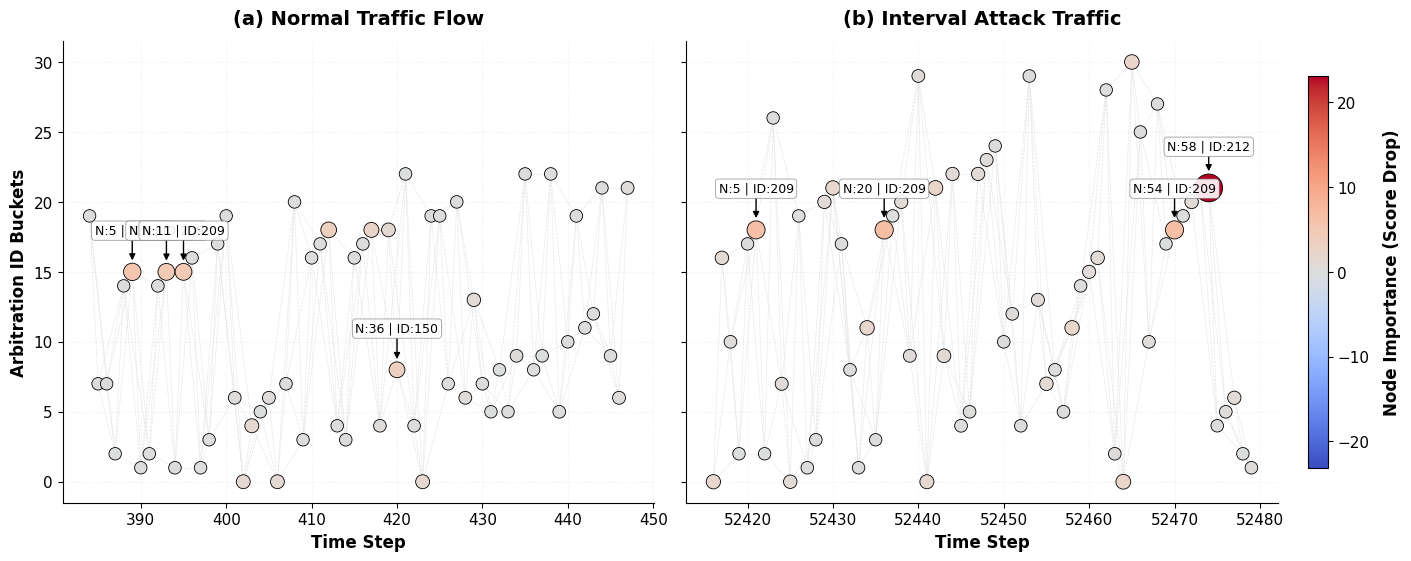

In [11]:
# plot_node_case_panels(
#     raw_normal=raw_normal,
#     raw_attack=raw_attack,
#     imp_normal=imp_normal,
#     imp_attack=imp_attack,
#     normal_title=f"Normal graph | true={normal_label_name} | pred={pred_name_normal}",
#     attack_title=f"Attack graph | true={attack_label_name} | pred={pred_name_attack}",
#     relation_filter=("temporal",),
#     top_k_labels=4,
#     figsize=(18, 6),
#     node_size=140,
# )

plot_node_case_panels(
    raw_normal=raw_normal,
    raw_attack=raw_attack,
    imp_normal=imp_normal,
    imp_attack=imp_attack,
    normal_title="(a) Normal Traffic Flow",
    attack_title="(b) Interval Attack Traffic",
    relation_filter=("temporal",),
    top_k_labels=4,
    figsize=(14, 5.5), # Tỷ lệ chuẩn để nhét vừa lề 2 cột của báo IEEE
    save_path="../figures/explainability/node_explanation_panels.pdf" # Lưu thẳng ra vector PDF
)

# Bạn nên ghi chú thông tin true/pred vào Caption trong file báo cáo, ví dụ: 
# "Figure X: Node-level importance comparison. (a) Normal graph correctly predicted as Normal. (b) Interval attack correctly predicted as Interval. Node sizes correlate with their importance score."


# Phần 2b — Node classification visualization trong từng graph/window

**Mục tiêu**: hiển thị trực quan node nào trong một window được mô hình dự đoán là attack.

Phần này dùng trực tiếp **node head** của checkpoint multitask:
- hàng **Ground truth**: nhãn node thật, chuyển về dạng `normal` / `attack`;
- hàng **Prediction**: nhãn node dự đoán, chuyển về dạng `normal` / `attack`;
- biểu đồ **attack probability**: xác suất node thuộc nhóm attack theo node head.

Vì checkpoint đang train với `node_target = node_y`, ta xem node là attack nếu `node_y != normal_class_id`. Cách này tránh dùng `node_is_attack` nếu field đó trong graph cũ từng bị tạo sai.


Trong phiên bản này, Figure 2b ưu tiên chọn một mixed window có ít nhất 3 attack nodes thật, graph-level prediction đúng, attack recall = 1.0, attack precision = 1.0, và binary node accuracy gần 1.0. Nếu không tìm được strict-perfect case, notebook sẽ chọn fallback tốt nhất theo cùng các tiêu chí.


In [15]:

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os


def parse_multitask_output(output):
    """Return graph_logits and node_logits from GraphAttentionKAN output."""
    if isinstance(output, dict):
        return output.get('graph_logits', None), output.get('node_logits', None)
    if isinstance(output, (tuple, list)):
        if len(output) >= 2:
            return output[0], output[1]
        if len(output) == 1:
            return output[0], None
    return output, None


def resolve_normal_class_id(label_mapping: Dict[int, str], normal_label: str = 'normal') -> int:
    normal_norm = normalize_label_name(normal_label)
    for idx, name in label_mapping.items():
        if normalize_label_name(name) == normal_norm:
            return int(idx)
    # fallback: class 0 is usually normal in this pipeline
    return 0


def get_node_label_names(label_ids, label_mapping: Dict[int, str]):
    return [label_mapping.get(int(i), f'class_{int(i)}') for i in label_ids]


def get_single_graph_node_classification(
    model,
    data: Data,
    label_mapping: Dict[int, str],
    device: str = 'cpu',
    node_target: str = 'node_y',
    normal_label: str = 'normal',
):
    """
    Run one graph/window through the model and collect node-level predictions.

    Returns a dictionary containing multiclass node prediction and binary
    normal/attack conversion for visualization.
    """
    model.eval()
    normal_class_id = resolve_normal_class_id(label_mapping, normal_label)

    data_in = clone_data(data).to(device)
    data_in.x = data_in.x.float()
    data_in.edge_index = data_in.edge_index.long()
    if hasattr(data_in, 'edge_attr'):
        data_in.edge_attr = data_in.edge_attr.float()
    if hasattr(data_in, 'edge_type'):
        data_in.edge_type = data_in.edge_type.long()
    if hasattr(data_in, 'id_token'):
        data_in.id_token = data_in.id_token.long()

    with torch.no_grad():
        output = model(data_in, return_node_logits=True)
        graph_logits, node_logits = parse_multitask_output(output)

        if graph_logits is None:
            raise RuntimeError('Model did not return graph_logits.')
        if node_logits is None:
            raise RuntimeError('Model did not return node_logits. Check num_node_classes and checkpoint loading.')

        graph_prob = F.softmax(graph_logits, dim=1)
        graph_pred = graph_prob.argmax(dim=1)

        node_prob = F.softmax(node_logits, dim=1)
        node_pred = node_prob.argmax(dim=1)
        node_conf = node_prob.max(dim=1).values

        # Attack probability:
        # for node_y multiclass: P(attack) = 1 - P(normal)
        # for node_is_attack binary: P(attack) = P(class 1)
        if node_prob.size(1) == 2 and node_target == 'node_is_attack':
            attack_prob = node_prob[:, 1]
            pred_is_attack = node_pred == 1
        else:
            attack_prob = 1.0 - node_prob[:, normal_class_id]
            pred_is_attack = node_pred != normal_class_id

    if not hasattr(data, node_target):
        raise AttributeError(f'Data object does not have node target: {node_target}')

    node_true = getattr(data, node_target).view(-1).detach().cpu().long()
    node_pred_cpu = node_pred.detach().cpu().long()
    node_prob_cpu = node_prob.detach().cpu()
    node_conf_cpu = node_conf.detach().cpu()
    attack_prob_cpu = attack_prob.detach().cpu()

    if hasattr(data, 'node_mask'):
        node_mask = data.node_mask.view(-1).detach().cpu().bool()
    else:
        node_mask = torch.ones_like(node_true, dtype=torch.bool)

    if node_target == 'node_is_attack':
        true_is_attack = node_true == 1
    else:
        true_is_attack = node_true != normal_class_id

    # Basic node-level summary on the selected graph
    valid = node_mask.numpy().astype(bool)
    true_bin = true_is_attack.numpy()[valid].astype(int)
    pred_bin = pred_is_attack.detach().cpu().numpy()[valid].astype(int)
    bin_acc = float((true_bin == pred_bin).mean()) if valid.sum() > 0 else 0.0

    return {
        'graph_id': getattr(data, 'graph_id', 'unknown_graph'),
        'window_label': getattr(data, 'window_label', None),
        'source_class': getattr(data, 'source_class', None),
        'graph_true_idx': int(data.y.view(-1)[0].item()),
        'graph_pred_idx': int(graph_pred.item()),
        'graph_true_name': label_mapping.get(int(data.y.view(-1)[0].item()), f'class_{int(data.y.view(-1)[0].item())}'),
        'graph_pred_name': label_mapping.get(int(graph_pred.item()), f'class_{int(graph_pred.item())}'),
        'graph_prob': graph_prob.detach().cpu(),
        'node_true': node_true,
        'node_pred': node_pred_cpu,
        'node_prob': node_prob_cpu,
        'node_conf': node_conf_cpu,
        'attack_prob': attack_prob_cpu,
        'node_mask': node_mask,
        'true_is_attack': true_is_attack.detach().cpu().bool(),
        'pred_is_attack': pred_is_attack.detach().cpu().bool(),
        'normal_class_id': normal_class_id,
        'normal_label': label_mapping.get(normal_class_id, str(normal_label)),
        'binary_attack_acc': bin_acc,
        'num_attack_true': int(true_is_attack[node_mask].sum().item()),
        'num_attack_pred': int(pred_is_attack.detach().cpu()[node_mask].sum().item()),
        'num_nodes': int(node_mask.sum().item()),
    }


def node_classification_result_to_df(result, data: Data, label_mapping: Dict[int, str]) -> pd.DataFrame:
    """Convert node classification result into an easy-to-check dataframe."""
    n = int(result['node_true'].numel())
    df = pd.DataFrame({
        'node_idx': np.arange(n),
        'node_mask': result['node_mask'].numpy().astype(bool),
        'true_label_id': result['node_true'].numpy().astype(int),
        'pred_label_id': result['node_pred'].numpy().astype(int),
        'true_label': get_node_label_names(result['node_true'].numpy(), label_mapping),
        'pred_label': get_node_label_names(result['node_pred'].numpy(), label_mapping),
        'true_is_attack': result['true_is_attack'].numpy().astype(bool),
        'pred_is_attack': result['pred_is_attack'].numpy().astype(bool),
        'attack_prob': result['attack_prob'].numpy(),
        'node_confidence': result['node_conf'].numpy(),
    })
    if hasattr(data, 'arbitration_id'):
        df['arbitration_id'] = data.arbitration_id.detach().cpu().numpy().astype(int)
    if hasattr(data, 'timestamp'):
        df['timestamp'] = data.timestamp.detach().cpu().numpy()
    if hasattr(data, 'msg_idx_in_file'):
        df['msg_idx_in_file'] = data.msg_idx_in_file.detach().cpu().numpy().astype(int)
    df['binary_correct'] = df['true_is_attack'] == df['pred_is_attack']
    df['multiclass_correct'] = df['true_label_id'] == df['pred_label_id']
    return df


def find_mixed_node_graph(
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    normal_label: str = 'normal',
    prefer_label: Optional[str] = None,
    max_scan: int = 5000,
):
    """
    Find a graph/window containing both normal and attack nodes.

    If no mixed graph is found within max_scan, return None.
    """
    normal_id = resolve_normal_class_id(label_mapping, normal_label)
    prefer_norm = normalize_label_name(prefer_label) if prefer_label is not None else None
    scanned = 0

    # First pass: prefer selected attack label if provided
    for raw_g in iter_raw_graphs(graph_folder, split):
        scanned += 1
        if scanned > max_scan:
            break
        label_name = get_graph_label_name(raw_g, label_mapping)
        if prefer_norm is not None and normalize_label_name(label_name) != prefer_norm:
            continue
        data = graph_dict_to_data(raw_g)
        if not hasattr(data, 'node_y'):
            continue
        y = data.node_y.view(-1)
        has_normal = bool((y == normal_id).any().item())
        has_attack = bool((y != normal_id).any().item())
        if has_normal and has_attack:
            return raw_g, data, label_name

    # Second pass: any mixed graph
    scanned = 0
    for raw_g in iter_raw_graphs(graph_folder, split):
        scanned += 1
        if scanned > max_scan:
            break
        data = graph_dict_to_data(raw_g)
        if not hasattr(data, 'node_y'):
            continue
        label_name = get_graph_label_name(raw_g, label_mapping)
        y = data.node_y.view(-1)
        has_normal = bool((y == normal_id).any().item())
        has_attack = bool((y != normal_id).any().item())
        if has_normal and has_attack:
            return raw_g, data, label_name

    return None



def _binary_node_metrics_from_result(result: Dict[str, Any]) -> Dict[str, float]:
    """Compute binary normal/attack node metrics for one graph result."""
    mask = result['node_mask'].numpy().astype(bool)
    true_bin = result['true_is_attack'].numpy()[mask].astype(int)
    pred_bin = result['pred_is_attack'].numpy()[mask].astype(int)

    tp = int(((true_bin == 1) & (pred_bin == 1)).sum())
    tn = int(((true_bin == 0) & (pred_bin == 0)).sum())
    fp = int(((true_bin == 0) & (pred_bin == 1)).sum())
    fn = int(((true_bin == 1) & (pred_bin == 0)).sum())

    total = max(1, len(true_bin))
    acc = (tp + tn) / total
    attack_recall = tp / max(1, tp + fn)
    attack_precision = tp / max(1, tp + fp)
    attack_f1 = 2 * attack_precision * attack_recall / max(1e-12, attack_precision + attack_recall)
    exact_binary_match = bool(np.array_equal(true_bin, pred_bin))

    return {
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'num_nodes': int(total),
        'num_true_attack': int(tp + fn),
        'num_pred_attack': int(tp + fp),
        'binary_acc': float(acc),
        'attack_recall': float(attack_recall),
        'attack_precision': float(attack_precision),
        'attack_f1': float(attack_f1),
        'exact_binary_match': exact_binary_match,
        'graph_correct': bool(result['graph_true_idx'] == result['graph_pred_idx']),
    }


def find_successful_node_classification_graph(
    model,
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    device: str = 'cpu',
    node_target: str = 'node_y',
    normal_label: str = 'normal',
    prefer_label: Optional[str] = None,
    max_scan: int = 20000,
    min_attack_nodes: int = 1,
    require_graph_correct: bool = True,
    require_exact_binary_match: bool = True,
):
    """
    Find an informative mixed graph where node classification is successful.

    Priority:
      1) graph contains both normal and attack nodes;
      2) graph-level prediction is correct, if require_graph_correct=True;
      3) binary node status is exactly correct, if require_exact_binary_match=True;
      4) prefer the requested attack label if prefer_label is given.

    If no perfect case is found, return the best available mixed graph according to
    attack recall, binary accuracy, attack precision, and graph correctness.
    """
    normal_id = resolve_normal_class_id(label_mapping, normal_label)
    prefer_norm = normalize_label_name(prefer_label) if prefer_label is not None else None

    def candidate_iterator(prefer_only: bool):
        scanned = 0
        for raw_g in iter_raw_graphs(graph_folder, split):
            scanned += 1
            if scanned > max_scan:
                break
            label_name = get_graph_label_name(raw_g, label_mapping)
            if prefer_only and prefer_norm is not None and normalize_label_name(label_name) != prefer_norm:
                continue
            data = graph_dict_to_data(raw_g)
            if not hasattr(data, node_target):
                continue
            node_y = getattr(data, node_target).view(-1)
            if node_target == 'node_is_attack':
                true_attack = node_y == 1
                true_normal = node_y == 0
            else:
                true_attack = node_y != normal_id
                true_normal = node_y == normal_id
            num_attack = int(true_attack.sum().item())
            has_normal = bool(true_normal.any().item())
            has_attack = num_attack >= min_attack_nodes
            if not (has_normal and has_attack):
                continue
            yield raw_g, data, label_name

    best = None
    best_score = None

    # pass 1: preferred label if possible; pass 2: any mixed label
    for prefer_only in ([True, False] if prefer_norm is not None else [False]):
        for raw_g, data, label_name in candidate_iterator(prefer_only=prefer_only):
            result = get_single_graph_node_classification(
                model=model,
                data=data,
                label_mapping=label_mapping,
                device=device,
                node_target=node_target,
                normal_label=normal_label,
            )
            metrics = _binary_node_metrics_from_result(result)

            graph_ok = (metrics['graph_correct'] or not require_graph_correct)
            node_ok = (metrics['exact_binary_match'] or not require_exact_binary_match)
            if graph_ok and node_ok:
                return {
                    'raw_graph': raw_g,
                    'data': data,
                    'label_name': label_name,
                    'result': result,
                    'metrics': metrics,
                    'selection_status': 'perfect_match',
                }

            # Keep best fallback. Higher score is better.
            score = (
                int(metrics['graph_correct']),
                metrics['attack_recall'],
                metrics['binary_acc'],
                metrics['attack_precision'],
                metrics['attack_f1'],
                -abs(metrics['num_true_attack'] - metrics['num_pred_attack']),
            )
            if best_score is None or score > best_score:
                best_score = score
                best = {
                    'raw_graph': raw_g,
                    'data': data,
                    'label_name': label_name,
                    'result': result,
                    'metrics': metrics,
                    'selection_status': 'best_fallback',
                }

        # If pass 1 already found a good fallback with preferred label, do not stop;
        # pass 2 may still find a perfect graph from another class.

    return best



def find_successful_node_classification_graph_strict(
    model,
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    device: str = 'cpu',
    node_target: str = 'node_y',
    normal_label: str = 'normal',
    prefer_label: Optional[str] = None,
    max_scan: int = 30000,
    min_true_attack_nodes: int = 3,
    max_true_attack_nodes: Optional[int] = 10,
    min_tp_attack_nodes: int = 2,
    min_binary_node_acc: float = 0.99,
    max_attack_ratio: float = 0.20,
    require_graph_correct: bool = True,
):
    """
    Select an informative attack/mixed graph for Figure 2b.

    Strict target criteria:
      - the graph contains both normal nodes and attack nodes;
      - number of true attack nodes >= min_true_attack_nodes;
      - number of correctly detected attack nodes TP >= min_tp_attack_nodes;
      - graph-level prediction is correct, if require_graph_correct=True;
      - node-level attack recall = 1.0;
      - node-level attack precision = 1.0;
      - binary node accuracy is close to 1.0, controlled by min_binary_node_acc.

    If no strict-perfect graph is found, the function returns the best fallback
    that still satisfies the minimum number of true attack nodes. The fallback is
    ranked by graph correctness, attack recall, attack precision, binary accuracy,
    and the number of true attack nodes.
    """
    normal_id = resolve_normal_class_id(label_mapping, normal_label)
    prefer_norm = normalize_label_name(prefer_label) if prefer_label is not None else None
    eps = 1e-12

    candidates = []

    def scan(prefer_only: bool, min_attack_required: int):
        scanned = 0
        for raw_g in iter_raw_graphs(graph_folder, split):
            scanned += 1
            if scanned > max_scan:
                break

            label_name = get_graph_label_name(raw_g, label_mapping)
            if prefer_only and prefer_norm is not None and normalize_label_name(label_name) != prefer_norm:
                continue

            data = graph_dict_to_data(raw_g)
            if not hasattr(data, node_target):
                continue

            node_y = getattr(data, node_target).view(-1)
            if hasattr(data, 'node_mask'):
                node_mask = data.node_mask.view(-1).bool()
            else:
                node_mask = torch.ones_like(node_y, dtype=torch.bool)

            if node_target == 'node_is_attack':
                true_attack = (node_y == 1) & node_mask
                true_normal = (node_y == 0) & node_mask
            else:
                true_attack = (node_y != normal_id) & node_mask
                true_normal = (node_y == normal_id) & node_mask

            true_attack_count = int(true_attack.sum().item())
            valid_count = int(node_mask.sum().item())
            attack_ratio = true_attack_count / max(valid_count, 1)

            # mixed window requirement and attack-node range requirement
            if not bool(true_normal.any().item()):
                continue

            if true_attack_count < min_attack_required:
                continue

            # Avoid attack-dominant windows for cleaner visualization
            if max_true_attack_nodes is not None and true_attack_count > max_true_attack_nodes:
                continue

            if max_attack_ratio is not None and attack_ratio > max_attack_ratio:
                continue

            result = get_single_graph_node_classification(
                model=model,
                data=data,
                label_mapping=label_mapping,
                device=device,
                node_target=node_target,
                normal_label=normal_label,
            )
            metrics = _binary_node_metrics_from_result(result)

            graph_ok = bool(metrics['graph_correct']) or not require_graph_correct
            recall_ok = metrics['attack_recall'] >= 1.0 - eps
            precision_ok = metrics['attack_precision'] >= 1.0 - eps
            tp_ok = metrics['tp'] >= min_tp_attack_nodes
            acc_ok = metrics['binary_acc'] >= min_binary_node_acc

            strict_ok = bool(graph_ok and recall_ok and precision_ok and tp_ok and acc_ok)

            # Higher score is better. Strict cases always rank above fallback cases.
            score = (
                int(strict_ok),
                int(metrics['graph_correct']),
                metrics['attack_recall'],
                metrics['attack_precision'],
                metrics['binary_acc'],
                metrics['tp'],
                metrics['num_true_attack'],
                -metrics['fp'],
                -metrics['fn'],
                -abs(metrics['num_true_attack'] - metrics['num_pred_attack']),
            )

            candidates.append({
                'raw_graph': raw_g,
                'data': data,
                'label_name': label_name,
                'result': result,
                'metrics': metrics,
                'selection_status': 'strict_perfect_match' if strict_ok else 'best_fallback',
                'score': score,
                'attack_ratio': attack_ratio,
                'strict_ok': strict_ok,
                'min_attack_required': min_attack_required,
            })

    # Pass 1: preferred attack label, if available. Pass 2: any label.
    for prefer_only in ([True, False] if prefer_norm is not None else [False]):
        scan(prefer_only=prefer_only, min_attack_required=min_true_attack_nodes)

    if len(candidates) == 0:
        # Relaxed fallback: at least 2 true attack nodes if no graph with >=3 is found.
        relaxed_min_attack = max(2, min_tp_attack_nodes)
        print(
            f"No candidate found with true_attack_count >= {min_true_attack_nodes}. "
            f"Relaxing to true_attack_count >= {relaxed_min_attack}."
        )
        for prefer_only in ([True, False] if prefer_norm is not None else [False]):
            scan(prefer_only=prefer_only, min_attack_required=relaxed_min_attack)

    if len(candidates) == 0:
        return None

    candidates = sorted(candidates, key=lambda x: x['score'], reverse=True)
    best = candidates[0]

    # If the best was from the relaxed fallback, make the status explicit.
    if best['min_attack_required'] < min_true_attack_nodes and best['selection_status'] == 'best_fallback':
        best['selection_status'] = 'relaxed_best_fallback'
    elif best['min_attack_required'] < min_true_attack_nodes and best['selection_status'] == 'strict_perfect_match':
        best['selection_status'] = 'relaxed_strict_perfect_match'

    return best



# ============================================================
# Faster graph selection for Figure 2b
# ============================================================
# This optimized selector keeps the existing plotting code unchanged.
# It only changes how the attack/mixed graph is selected:
#   1) CPU pre-filter by ground-truth node labels;
#   2) support multiple preferred attack labels;
#   3) run the model only on a small number of candidates;
#   4) use batched inference instead of one-graph-at-a-time inference.

from torch_geometric.loader import DataLoader


def _normalize_prefer_labels(prefer_labels=None, prefer_label=None):
    """Accept either prefer_labels=[...] or old prefer_label='...' for backward compatibility."""
    labels = []
    if prefer_labels is not None:
        if isinstance(prefer_labels, str):
            labels = [prefer_labels]
        else:
            labels = list(prefer_labels)
    elif prefer_label is not None:
        labels = [prefer_label]

    labels = [str(x) for x in labels if x is not None and str(x).strip() != ""]
    return labels


def _graph_label_matches_preference(label_name: str, prefer_norm_list):
    if not prefer_norm_list:
        return True
    return normalize_label_name(label_name) in prefer_norm_list


def _true_attack_summary_from_data(
    data: Data,
    normal_id: int,
    node_target: str = "node_y",
):
    """Fast CPU-only summary from node labels. No model forward is needed."""
    if not hasattr(data, node_target):
        return None

    node_y = getattr(data, node_target).view(-1).detach().cpu().long()

    if hasattr(data, "node_mask"):
        node_mask = data.node_mask.view(-1).detach().cpu().bool()
    else:
        node_mask = torch.ones_like(node_y, dtype=torch.bool)

    valid_y = node_y[node_mask]
    if valid_y.numel() == 0:
        return None

    if node_target == "node_is_attack":
        true_attack = valid_y == 1
        true_normal = valid_y == 0
        attack_classes = [1] if bool(true_attack.any().item()) else []
    else:
        true_attack = valid_y != int(normal_id)
        true_normal = valid_y == int(normal_id)
        attack_classes = sorted(set(valid_y[true_attack].cpu().numpy().astype(int).tolist()))

    return {
        "valid_count": int(valid_y.numel()),
        "true_attack_count": int(true_attack.sum().item()),
        "true_normal_count": int(true_normal.sum().item()),
        "attack_ratio": float(true_attack.sum().item() / max(valid_y.numel(), 1)),
        "attack_classes": attack_classes,
        "num_attack_classes": len(attack_classes),
    }


def _prefilter_candidate_graphs_fast(
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    node_target: str,
    normal_label: str,
    prefer_labels=None,
    max_scan: int = 30000,
    min_true_attack_nodes: int = 3,
    max_true_attack_nodes: Optional[int] = 10,
    max_attack_ratio: Optional[float] = 0.20,
    min_true_attack_classes: int = 1,
    max_candidates_per_label: int = 250,
):
    """
    Fast CPU pre-filter.

    Returns a small list of candidate raw graphs/Data objects.
    This avoids running the model on the entire split.
    """
    normal_id = resolve_normal_class_id(label_mapping, normal_label)

    prefer_labels = _normalize_prefer_labels(prefer_labels=prefer_labels)
    prefer_norm_list = [normalize_label_name(x) for x in prefer_labels]

    # If prefer_labels is given, keep per-label quotas.
    per_label_counter = {normalize_label_name(x): 0 for x in prefer_labels}
    no_pref_counter = 0

    candidates = []
    scanned = 0

    for raw_g in iter_raw_graphs(graph_folder, split):
        scanned += 1
        if max_scan is not None and scanned > max_scan:
            break

        label_name = get_graph_label_name(raw_g, label_mapping)
        label_norm = normalize_label_name(label_name)

        # If multiple preferred labels are provided, skip labels outside the list.
        if prefer_norm_list and label_norm not in prefer_norm_list:
            continue

        # Per-label quota to avoid one frequent label dominating candidates.
        if prefer_norm_list:
            if per_label_counter.get(label_norm, 0) >= max_candidates_per_label:
                continue
        else:
            if no_pref_counter >= max_candidates_per_label:
                continue

        data = graph_dict_to_data(raw_g)
        summary = _true_attack_summary_from_data(
            data=data,
            normal_id=normal_id,
            node_target=node_target,
        )

        if summary is None:
            continue

        # Need a mixed graph: at least one normal node and at least some attack nodes.
        if summary["true_normal_count"] <= 0:
            continue

        if summary["true_attack_count"] < min_true_attack_nodes:
            continue

        if max_true_attack_nodes is not None and summary["true_attack_count"] > max_true_attack_nodes:
            continue

        if max_attack_ratio is not None and summary["attack_ratio"] > max_attack_ratio:
            continue

        if summary["num_attack_classes"] < min_true_attack_classes:
            continue

        # Store compact candidate
        if prefer_norm_list:
            per_label_counter[label_norm] = per_label_counter.get(label_norm, 0) + 1
            label_rank = prefer_norm_list.index(label_norm) if label_norm in prefer_norm_list else 10_000
        else:
            no_pref_counter += 1
            label_rank = 0

        candidates.append({
            "raw_graph": raw_g,
            "data": data,
            "label_name": label_name,
            "label_rank": label_rank,
            "summary": summary,
        })

        # Early stop when quotas are filled for all preferred labels.
        if prefer_norm_list and all(per_label_counter.get(x, 0) >= max_candidates_per_label for x in prefer_norm_list):
            break

    print("=" * 100)
    print("Fast CPU prefilter for Figure 2b")
    print(f"  scanned graphs             : {scanned}")
    print(f"  candidate graphs           : {len(candidates)}")
    print(f"  preferred labels           : {prefer_labels if prefer_labels else 'any attack label'}")
    if prefer_norm_list:
        print(f"  candidates per label       : {per_label_counter}")
    print(f"  true_attack_count range    : [{min_true_attack_nodes}, {max_true_attack_nodes}]")
    print(f"  max_attack_ratio           : {max_attack_ratio}")
    print(f"  min_true_attack_classes    : {min_true_attack_classes}")
    print("=" * 100)

    return candidates

from torch_geometric.data import Data
def clean_data_for_model_batch(data):
    """
    Keep only tensor attributes needed by the model and node visualization.
    This avoids PyG DataLoader errors caused by non-uniform dict metadata,
    e.g., KeyError: 'combined'.
    """
    clean = Data()

    # Required graph fields
    clean.x = data.x.float()
    clean.edge_index = data.edge_index.long()

    if hasattr(data, "edge_attr") and data.edge_attr is not None:
        clean.edge_attr = data.edge_attr.float()

    if hasattr(data, "edge_type") and data.edge_type is not None:
        clean.edge_type = data.edge_type.long()

    # ID token field
    if hasattr(data, "id_token") and data.id_token is not None:
        clean.id_token = data.id_token.long()
    elif hasattr(data, "id_index") and data.id_index is not None:
        clean.id_token = data.id_index.long()
    else:
        raise AttributeError("Data must contain id_token or id_index.")

    # Graph label
    clean.y = data.y.view(-1).long()

    # Node labels
    if hasattr(data, "node_y") and data.node_y is not None:
        clean.node_y = data.node_y.long()

    if hasattr(data, "node_mask") and data.node_mask is not None:
        clean.node_mask = data.node_mask.bool()

    if hasattr(data, "node_is_attack") and data.node_is_attack is not None:
        clean.node_is_attack = data.node_is_attack.long()

    return clean

@torch.no_grad()
def _evaluate_candidate_batch_for_node_selection(
    model,
    candidate_batch,
    label_mapping: Dict[int, str],
    device: str,
    node_target: str,
    normal_label: str,
):
    """
    Run one batch of candidate graphs and return records compatible with
    the existing notebook variables:
        raw_graph, data, label_name, result, metrics, selection_status, score, attack_ratio
    """
    if len(candidate_batch) == 0:
        return []

    normal_id = resolve_normal_class_id(label_mapping, normal_label)

    data_list = [
        clean_data_for_model_batch(x["data"])
        for x in candidate_batch
    ]

    loader = DataLoader(data_list, batch_size=len(data_list), shuffle=False)
    batch = next(iter(loader)).to(device)

    batch.x = batch.x.float()
    batch.edge_index = batch.edge_index.long()
    if hasattr(batch, "edge_attr"):
        batch.edge_attr = batch.edge_attr.float()
    if hasattr(batch, "edge_type"):
        batch.edge_type = batch.edge_type.long()
    if hasattr(batch, "id_token"):
        batch.id_token = batch.id_token.long()

    output = model(batch, return_node_logits=True)
    graph_logits, node_logits = parse_multitask_output(output)

    if graph_logits is None:
        raise RuntimeError("Model did not return graph_logits.")
    if node_logits is None:
        raise RuntimeError("Model did not return node_logits. Check num_node_classes and checkpoint loading.")

    graph_prob = F.softmax(graph_logits, dim=1).detach().cpu()
    graph_pred = graph_prob.argmax(dim=1).detach().cpu().long()

    node_prob = F.softmax(node_logits, dim=1).detach().cpu()
    node_pred = node_prob.argmax(dim=1).detach().cpu().long()
    node_conf = node_prob.max(dim=1).values.detach().cpu()

    if node_prob.size(1) == 2 and node_target == "node_is_attack":
        attack_prob = node_prob[:, 1]
        pred_is_attack_all = node_pred == 1
    else:
        attack_prob = 1.0 - node_prob[:, normal_id]
        pred_is_attack_all = node_pred != normal_id

    node_true_all = getattr(batch, node_target).view(-1).detach().cpu().long()
    if hasattr(batch, "node_mask"):
        node_mask_all = batch.node_mask.view(-1).detach().cpu().bool()
    else:
        node_mask_all = torch.ones_like(node_true_all, dtype=torch.bool)

    batch_vec = batch.batch.detach().cpu().long()
    graph_true_all = batch.y.view(-1).detach().cpu().long()

    records = []

    for local_i, cand in enumerate(candidate_batch):
        node_sel = batch_vec == local_i
        data_i = cand["data"]

        node_true_i = node_true_all[node_sel].clone()
        node_pred_i = node_pred[node_sel].clone()
        node_prob_i = node_prob[node_sel].clone()
        node_conf_i = node_conf[node_sel].clone()
        attack_prob_i = attack_prob[node_sel].clone()
        node_mask_i = node_mask_all[node_sel].clone()

        if node_target == "node_is_attack":
            true_is_attack_i = node_true_i == 1
            pred_is_attack_i = node_pred_i == 1
        else:
            true_is_attack_i = node_true_i != int(normal_id)
            pred_is_attack_i = node_pred_i != int(normal_id)

        valid = node_mask_i.numpy().astype(bool)
        true_bin = true_is_attack_i.numpy()[valid].astype(int)
        pred_bin = pred_is_attack_i.numpy()[valid].astype(int)
        bin_acc = float((true_bin == pred_bin).mean()) if valid.sum() > 0 else 0.0

        graph_true_idx = int(graph_true_all[local_i].item())
        graph_pred_idx = int(graph_pred[local_i].item())

        result = {
            "graph_id": getattr(data_i, "graph_id", "unknown_graph"),
            "window_label": getattr(data_i, "window_label", None),
            "source_class": getattr(data_i, "source_class", None),
            "graph_true_idx": graph_true_idx,
            "graph_pred_idx": graph_pred_idx,
            "graph_true_name": label_mapping.get(graph_true_idx, f"class_{graph_true_idx}"),
            "graph_pred_name": label_mapping.get(graph_pred_idx, f"class_{graph_pred_idx}"),
            "graph_prob": graph_prob[local_i:local_i+1].clone(),
            "node_true": node_true_i,
            "node_pred": node_pred_i,
            "node_prob": node_prob_i,
            "node_conf": node_conf_i,
            "attack_prob": attack_prob_i,
            "node_mask": node_mask_i,
            "true_is_attack": true_is_attack_i.cpu().bool(),
            "pred_is_attack": pred_is_attack_i.cpu().bool(),
            "normal_class_id": normal_id,
            "normal_label": label_mapping.get(normal_id, str(normal_label)),
            "binary_attack_acc": bin_acc,
            "num_attack_true": int(true_is_attack_i[node_mask_i].sum().item()),
            "num_attack_pred": int(pred_is_attack_i[node_mask_i].sum().item()),
            "num_nodes": int(node_mask_i.sum().item()),
        }

        metrics = _binary_node_metrics_from_result(result)

        # Add multiclass node accuracy because this figure can visualize multiclass predictions.
        node_true_np = node_true_i.numpy()[valid]
        node_pred_np = node_pred_i.numpy()[valid]
        metrics["multiclass_acc"] = float((node_true_np == node_pred_np).mean()) if valid.sum() > 0 else 0.0

        true_attack_classes = sorted(set(node_true_i[true_is_attack_i & node_mask_i].numpy().astype(int).tolist()))
        pred_attack_classes = sorted(set(node_pred_i[pred_is_attack_i & node_mask_i].numpy().astype(int).tolist()))
        metrics["true_attack_classes"] = true_attack_classes
        metrics["pred_attack_classes"] = pred_attack_classes
        metrics["num_true_attack_classes"] = len(true_attack_classes)
        metrics["num_pred_attack_classes"] = len(pred_attack_classes)

        attack_ratio = metrics["num_true_attack"] / max(metrics["num_nodes"], 1)

        # Higher is better.
        # label_rank is inverted so labels earlier in PREFERRED_ATTACK_LABELS are preferred.
        score = (
            int(metrics["graph_correct"]),
            metrics["attack_recall"],
            metrics["attack_precision"],
            metrics["binary_acc"],
            metrics["multiclass_acc"],
            metrics["tp"],
            -cand.get("label_rank", 0),
            -abs(metrics["num_true_attack"] - 5),  # prefer visually moderate cases around 5 attack nodes
            -metrics["fp"],
            -metrics["fn"],
        )

        records.append({
            "raw_graph": cand["raw_graph"],
            "data": data_i,
            "label_name": cand["label_name"],
            "result": result,
            "metrics": metrics,
            "selection_status": "candidate_evaluated",
            "score": score,
            "attack_ratio": attack_ratio,
            "strict_ok": False,
            "label_rank": cand.get("label_rank", 0),
        })

    return records


def find_successful_node_classification_graph_fast(
    model,
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    device: str = "cpu",
    node_target: str = "node_y",
    normal_label: str = "normal",
    prefer_labels=None,
    prefer_label: Optional[str] = None,
    max_scan: int = 30000,
    min_true_attack_nodes: int = 3,
    max_true_attack_nodes: Optional[int] = 10,
    min_tp_attack_nodes: int = 2,
    min_binary_node_acc: float = 0.99,
    max_attack_ratio: Optional[float] = 0.20,
    min_true_attack_classes: int = 1,
    require_graph_correct: bool = True,
    batch_size: int = 256,
    max_candidates_per_label: int = 250,
    early_stop_after_strict: bool = True,
):
    """
    Optimized selector for Figure 2b.

    It can search across multiple attack labels, e.g.
        prefer_labels=['fuzzing', 'systematic', 'speed', 'combined', 'interval', 'dos']

    The existing plotting code can stay unchanged because the returned object
    has the same structure as the old selector.
    """
    prefer_labels = _normalize_prefer_labels(prefer_labels=prefer_labels, prefer_label=prefer_label)
    eps = 1e-12

    candidates = _prefilter_candidate_graphs_fast(
        graph_folder=graph_folder,
        split=split,
        label_mapping=label_mapping,
        node_target=node_target,
        normal_label=normal_label,
        prefer_labels=prefer_labels,
        max_scan=max_scan,
        min_true_attack_nodes=min_true_attack_nodes,
        max_true_attack_nodes=max_true_attack_nodes,
        max_attack_ratio=max_attack_ratio,
        min_true_attack_classes=min_true_attack_classes,
        max_candidates_per_label=max_candidates_per_label,
    )

    if len(candidates) == 0 and min_true_attack_classes > 1:
        print(
            f"No candidate found with at least {min_true_attack_classes} attack classes. "
            "Relaxing min_true_attack_classes to 1."
        )
        candidates = _prefilter_candidate_graphs_fast(
            graph_folder=graph_folder,
            split=split,
            label_mapping=label_mapping,
            node_target=node_target,
            normal_label=normal_label,
            prefer_labels=prefer_labels,
            max_scan=max_scan,
            min_true_attack_nodes=min_true_attack_nodes,
            max_true_attack_nodes=max_true_attack_nodes,
            max_attack_ratio=max_attack_ratio,
            min_true_attack_classes=1,
            max_candidates_per_label=max_candidates_per_label,
        )

    if len(candidates) == 0:
        print("No candidate found after CPU prefilter.")
        return None

    model.eval()

    all_records = []
    strict_records = []

    for start in range(0, len(candidates), batch_size):
        cand_batch = candidates[start:start + batch_size]

        batch_records = _evaluate_candidate_batch_for_node_selection(
            model=model,
            candidate_batch=cand_batch,
            label_mapping=label_mapping,
            device=device,
            node_target=node_target,
            normal_label=normal_label,
        )

        for rec in batch_records:
            m = rec["metrics"]

            graph_ok = bool(m["graph_correct"]) or not require_graph_correct
            recall_ok = m["attack_recall"] >= 1.0 - eps
            precision_ok = m["attack_precision"] >= 1.0 - eps
            tp_ok = m["tp"] >= min_tp_attack_nodes
            acc_ok = m["binary_acc"] >= min_binary_node_acc

            strict_ok = bool(graph_ok and recall_ok and precision_ok and tp_ok and acc_ok)
            rec["strict_ok"] = strict_ok
            rec["selection_status"] = "strict_perfect_match" if strict_ok else "best_fallback"

            all_records.append(rec)
            if strict_ok:
                strict_records.append(rec)

        if early_stop_after_strict and len(strict_records) > 0:
            break

    if len(all_records) == 0:
        return None

    if len(strict_records) > 0:
        best = sorted(strict_records, key=lambda x: x["score"], reverse=True)[0]
        best["selection_status"] = "strict_perfect_match"
    else:
        best = sorted(all_records, key=lambda x: x["score"], reverse=True)[0]
        best["selection_status"] = "best_fallback"

    return best



In [16]:

def plot_node_classification_timeline(
    result: Dict[str, Any],
    title: Optional[str] = None,
    save_path: Optional[str] = None,
    figsize=(13.5, 2.8),
    show_error_marks: bool = True,
):
    """
    Two-row timeline:
        row 1: ground-truth normal/attack node status
        row 2: predicted normal/attack node status
    """
    true_bin = result['true_is_attack'].numpy().astype(int)
    pred_bin = result['pred_is_attack'].numpy().astype(int)
    node_mask = result['node_mask'].numpy().astype(bool)
    n = len(true_bin)

    # Use only valid nodes for plotting, but keep original index order.
    idx = np.where(node_mask)[0]
    plot_mat = np.vstack([true_bin[idx], pred_bin[idx]])

    plt.rcParams.update({
        'axes.labelsize': 11,
        'font.size': 11,
        'legend.fontsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 11,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
    })

    cmap = ListedColormap(['#4C78A8', '#E45756'])  # normal, attack
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(plot_mat, aspect='auto', interpolation='nearest', cmap=cmap, vmin=0, vmax=1)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Ground truth', 'Prediction'])
    ax.set_xlabel('Node index within graph window')

    # keep readable ticks for 64-node windows
    step = max(1, len(idx) // 16)
    ax.set_xticks(np.arange(0, len(idx), step))
    ax.set_xticklabels(idx[::step])

    if show_error_marks:
        wrong = np.where((true_bin[idx] != pred_bin[idx]))[0]
        if len(wrong) > 0:
            ax.scatter(wrong, np.ones_like(wrong), marker='x', s=45, c='black', linewidths=1.2, label='Mismatch')

    if title is None:
        title = (
            f"{result['graph_id']} | true={result['graph_true_name']} | "
            f"pred={result['graph_pred_name']} | binary node acc={result['binary_attack_acc']:.3f}"
        )
    ax.set_title(title, pad=10, fontweight='bold')

    legend_handles = [
        Patch(facecolor='#4C78A8', label='Normal node'),
        Patch(facecolor='#E45756', label='Attack node'),
    ]
    if show_error_marks and np.any(true_bin[idx] != pred_bin[idx]):
        legend_handles.append(Line2D([0], [0], marker='x', color='black', linestyle='None', label='Mismatch'))
    ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.0, 1.38), ncol=len(legend_handles), frameon=False)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='y', length=0)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format=save_path.split('.')[-1])
        print(f'[*] Saved node classification timeline to: {save_path}')

    plt.show()
    plt.rcdefaults()


def plot_node_attack_probability(
    result: Dict[str, Any],
    title: Optional[str] = None,
    save_path: Optional[str] = None,
    figsize=(13.5, 3.2),
):
    """Plot node-level attack probability predicted by node head."""
    attack_prob = result['attack_prob'].numpy()
    true_bin = result['true_is_attack'].numpy().astype(int)
    pred_bin = result['pred_is_attack'].numpy().astype(int)
    mask = result['node_mask'].numpy().astype(bool)
    idx = np.where(mask)[0]

    plt.rcParams.update({
        'axes.labelsize': 11,
        'font.size': 11,
        'legend.fontsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 10,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
    })

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    colors = ['#E45756' if v == 1 else '#4C78A8' for v in true_bin[idx]]
    ax.bar(np.arange(len(idx)), attack_prob[idx], color=colors, alpha=0.85, width=0.85)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1.0, alpha=0.75)

    # Mark binary prediction errors
    wrong = np.where(true_bin[idx] != pred_bin[idx])[0]
    if len(wrong) > 0:
        ax.scatter(wrong, attack_prob[idx][wrong], marker='x', c='black', s=45, linewidths=1.2, zorder=4)

    step = max(1, len(idx) // 16)
    ax.set_xticks(np.arange(0, len(idx), step))
    ax.set_xticklabels(idx[::step])
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Node index within graph window')
    ax.set_ylabel('Predicted attack probability')
    if title is None:
        title = f"Node attack probability | {result['graph_id']}"
    ax.set_title(title, pad=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle=':')

    legend_handles = [
        Patch(facecolor='#4C78A8', label='True normal'),
        Patch(facecolor='#E45756', label='True attack'),
        Line2D([0], [0], color='black', linestyle='--', label='0.5 threshold'),
    ]
    if len(wrong) > 0:
        legend_handles.append(Line2D([0], [0], marker='x', color='black', linestyle='None', label='Mismatch'))
    ax.legend(handles=legend_handles, loc='upper right', ncol=2, frameon=False)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format=save_path.split('.')[-1])
        print(f'[*] Saved node attack probability plot to: {save_path}')

    plt.show()
    plt.rcdefaults()


def summarize_node_classification(result: Dict[str, Any], name: str = 'graph'):
    print(f"[{name}] graph_id         : {result['graph_id']}")
    print(f"[{name}] graph true/pred  : {result['graph_true_name']} -> {result['graph_pred_name']}")
    print(f"[{name}] nodes            : {result['num_nodes']}")
    print(f"[{name}] true attack nodes: {result['num_attack_true']}")
    print(f"[{name}] pred attack nodes: {result['num_attack_pred']}")
    print(f"[{name}] binary node acc  : {result['binary_attack_acc']:.4f}")


In [17]:
# ------------------------------------------------------------
# Select graphs for node-classification visualization
# ------------------------------------------------------------
normal_class_id = resolve_normal_class_id(ckpt_label_mapping, resolved_normal_label)
node_target_for_vis = ckpt.get('args', {}).get('node_target', 'node_y')

print('normal_class_id =', normal_class_id, '| normal label =', ckpt_label_mapping.get(normal_class_id))
print('node_target_for_vis =', node_target_for_vis)

# Run node head on the selected normal graph.
# This graph is used to show that the node head does not raise false alarms
# in a normal window.
node_cls_normal = get_single_graph_node_classification(
    model=model,
    data=data_normal,
    label_mapping=ckpt_label_mapping,
    device=DEVICE,
    node_target=node_target_for_vis,
    normal_label=resolved_normal_label,
)

# ------------------------------------------------------------
# Faster and more robust selection for Figure 2b
# ------------------------------------------------------------
# Recommended target classes for visualization:
#   - fuzzing/systematic/speed/combined: more informative than DoS because they are less saturated;
#   - interval/dos: easier fallback classes with high node-level performance;
#   - gear/rpm: included later as fallback, but they are harder according to the node report.
#
# The selector searches across these labels instead of using only the single
# attack_label_name selected earlier in the notebook.
PREFERRED_ATTACK_LABELS_FOR_VIS = [
    'fuzzing',
    'systematic',
    'speed',
    'combined',
    'interval',
    'dos',
    'gear',
    'rpm',
]

# Strict target:
#   - 3 <= true_attack_count <= 10;
#   - at least 2 correctly detected attack nodes;
#   - graph prediction is correct;
#   - attack recall = 1.0;
#   - attack precision = 1.0;
#   - binary node accuracy is close to 1.0.
MIN_TRUE_ATTACK_NODES = 3
MAX_TRUE_ATTACK_NODES = 5
MIN_TP_ATTACK_NODES = 2
MIN_BINARY_NODE_ACC = 0.99
MAX_ATTACK_RATIO = 0.20

# Usually each generated window contains one dominant attack type.
# Keep this as 1 for fast/reliable selection.
# If you specifically want a graph containing multiple attack classes,
# change this to 2, but it may be much slower or may not find a strict case.
MIN_TRUE_ATTACK_CLASSES = 1

selected_success = find_successful_node_classification_graph_fast(
    model=model,
    graph_folder=GRAPH_FOLDER,
    split=SPLIT,
    label_mapping=ckpt_label_mapping,
    device=DEVICE,
    node_target=node_target_for_vis,
    normal_label=resolved_normal_label,
    prefer_labels=PREFERRED_ATTACK_LABELS_FOR_VIS,
    max_scan=30000,
    min_true_attack_nodes=MIN_TRUE_ATTACK_NODES,
    max_true_attack_nodes=MAX_TRUE_ATTACK_NODES,
    min_tp_attack_nodes=MIN_TP_ATTACK_NODES,
    min_binary_node_acc=MIN_BINARY_NODE_ACC,
    max_attack_ratio=MAX_ATTACK_RATIO,
    min_true_attack_classes=MIN_TRUE_ATTACK_CLASSES,
    require_graph_correct=True,
    batch_size=256,
    max_candidates_per_label=150,
    early_stop_after_strict=True,
)

if selected_success is None:
    print('No suitable mixed graph found. Falling back to the previously selected attack graph.')
    raw_node_attack, data_node_attack, node_attack_label_name = raw_attack, data_attack, attack_label_name
    node_cls_attack = get_single_graph_node_classification(
        model=model,
        data=data_node_attack,
        label_mapping=ckpt_label_mapping,
        device=DEVICE,
        node_target=node_target_for_vis,
        normal_label=resolved_normal_label,
    )
    selection_status = 'fallback_original_attack_graph'
    selection_metrics = _binary_node_metrics_from_result(node_cls_attack)
    attack_ratio_selected = selection_metrics['num_true_attack'] / max(selection_metrics['num_nodes'], 1)
else:
    raw_node_attack = selected_success['raw_graph']
    data_node_attack = selected_success['data']
    node_attack_label_name = selected_success['label_name']
    node_cls_attack = selected_success['result']
    selection_status = selected_success['selection_status']
    selection_metrics = selected_success['metrics']
    attack_ratio_selected = selected_success.get(
        'attack_ratio',
        selection_metrics['num_true_attack'] / max(selection_metrics['num_nodes'], 1)
    )


def _class_ids_to_names(ids, label_mapping):
    return [label_mapping.get(int(i), f'class_{int(i)}') for i in ids]


print('\nSelected graph for Figure 2b')
print('  status              :', selection_status)
print('  graph_id            :', data_node_attack.graph_id)
print('  graph label         :', node_attack_label_name)
print('  preferred labels    :', PREFERRED_ATTACK_LABELS_FOR_VIS)
print('  graph true/pred     :', node_cls_attack['graph_true_name'], '->', node_cls_attack['graph_pred_name'])
print('  graph_correct       :', selection_metrics['graph_correct'])
print(
    '  true attack nodes   :',
    selection_metrics['num_true_attack'],
    f'(required {MIN_TRUE_ATTACK_NODES} <= count <= {MAX_TRUE_ATTACK_NODES})'
)
print('  pred attack nodes   :', selection_metrics['num_pred_attack'])
print('  attack ratio        :', f"{attack_ratio_selected:.4f}", f'(target <= {MAX_ATTACK_RATIO})')
print(
    '  true attack classes :',
    _class_ids_to_names(selection_metrics.get('true_attack_classes', []), ckpt_label_mapping)
)
print(
    '  pred attack classes :',
    _class_ids_to_names(selection_metrics.get('pred_attack_classes', []), ckpt_label_mapping)
)
print('  TP / FP / FN / TN   :', selection_metrics['tp'], '/', selection_metrics['fp'], '/', selection_metrics['fn'], '/', selection_metrics['tn'])
print('  TP attack nodes     :', selection_metrics['tp'], f'(required >= {MIN_TP_ATTACK_NODES})')
print('  binary node acc     :', f"{selection_metrics['binary_acc']:.4f}", f'(target >= {MIN_BINARY_NODE_ACC})')
print('  attack recall       :', f"{selection_metrics['attack_recall']:.4f}", '(target = 1.0)')
print('  attack precision    :', f"{selection_metrics['attack_precision']:.4f}", '(target = 1.0)')
if 'multiclass_acc' in selection_metrics:
    print('  multiclass node acc :', f"{selection_metrics['multiclass_acc']:.4f}")

if selection_status not in {'strict_perfect_match', 'relaxed_strict_perfect_match'}:
    print('\n[Warning] A strict perfect case was not found. The selected graph is the best fallback under the ranking criteria.')

summarize_node_classification(node_cls_normal, name='normal case')
summarize_node_classification(node_cls_attack, name='selected successful attack/mixed case')

# Save detailed per-node prediction tables
node_cls_dir = Path('../figures/explainability')
node_cls_dir.mkdir(parents=True, exist_ok=True)

node_normal_df = node_classification_result_to_df(node_cls_normal, data_normal, ckpt_label_mapping)
node_attack_df = node_classification_result_to_df(node_cls_attack, data_node_attack, ckpt_label_mapping)

node_normal_df.to_csv(node_cls_dir / 'node_classification_normal_case.csv', index=False)
node_attack_df.to_csv(node_cls_dir / 'node_classification_successful_attack_case.csv', index=False)

print('[*] Saved node prediction CSV files:')
print('   ', node_cls_dir / 'node_classification_normal_case.csv')
print('   ', node_cls_dir / 'node_classification_successful_attack_case.csv')

display(node_attack_df)


normal_class_id = 0 | normal label = normal
node_target_for_vis = node_y
Fast CPU prefilter for Figure 2b
  scanned graphs             : 30001
  candidate graphs           : 832
  preferred labels           : ['fuzzing', 'systematic', 'speed', 'combined', 'interval', 'dos', 'gear', 'rpm']
  candidates per label       : {'fuzzing': 142, 'systematic': 0, 'speed': 150, 'combined': 150, 'interval': 150, 'dos': 0, 'gear': 90, 'rpm': 150}
  true_attack_count range    : [3, 5]
  max_attack_ratio           : 0.2
  min_true_attack_classes    : 1

Selected graph for Figure 2b
  status              : strict_perfect_match
  graph_id            : combined__01342784_01342848
  graph label         : combined
  preferred labels    : ['fuzzing', 'systematic', 'speed', 'combined', 'interval', 'dos', 'gear', 'rpm']
  graph true/pred     : combined -> combined
  graph_correct       : True
  true attack nodes   : 5 (required 3 <= count <= 5)
  pred attack nodes   : 5
  attack ratio        : 0.0781 (target 

,node_idx,node_mask,true_label_id,pred_label_id,true_label,pred_label,true_is_attack,pred_is_attack,attack_prob,node_confidence,arbitration_id,timestamp,msg_idx_in_file,binary_correct,multiclass_correct
0,0,True,0,0,normal,normal,False,False,0.000000e+00,1.000000,376,1.672531e+09,1342784,True,True
1,1,True,0,0,normal,normal,False,False,2.384186e-07,1.000000,280,1.672531e+09,1342785,True,True
2,2,True,0,0,normal,normal,False,False,0.000000e+00,1.000000,2,1.672531e+09,1342786,True,True
3,3,True,0,0,normal,normal,False,False,7.152557e-07,0.999999,371,1.672531e+09,1342787,True,True
4,4,True,0,0,normal,normal,False,False,0.000000e+00,1.000000,576,1.672531e+09,1342788,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,59,True,0,0,normal,normal,False,False,0.000000e+00,1.000000,149,1.672531e+09,1342843,True,True
60,60,True,0,0,normal,normal,False,False,3.682971e-03,0.996317,152,1.672531e+09,1342844,True,True
61,61,True,0,0,normal,normal,False,False,8.344650e-07,0.999999,140,1.672531e+09,1342845,True,True
62,62,True,0,0,normal,normal,False,False,1.192093e-07,1.000000,361,1.672531e+09,1342846,True,True


[*] Saved node classification timeline to: ../figures/explainability/node_classification_timeline_normal.pdf


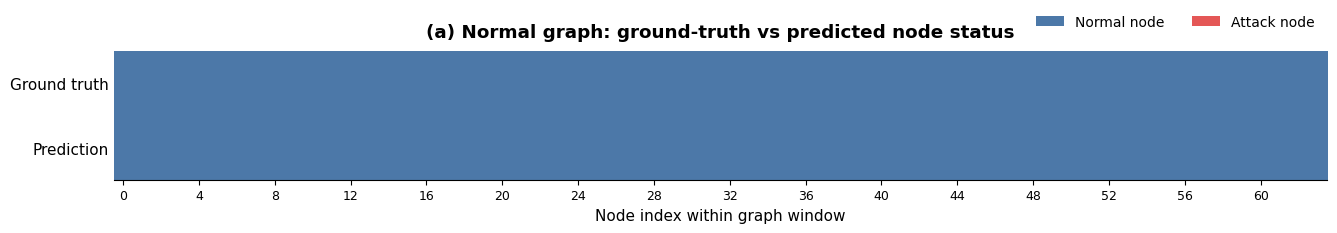

[*] Saved node classification timeline to: ../figures/explainability/node_classification_timeline_successful_attack.pdf


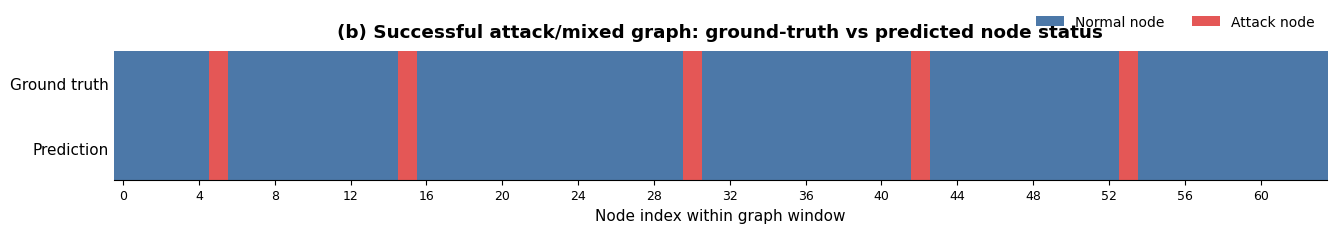

[*] Saved node attack probability plot to: ../figures/explainability/node_attack_probability_successful_attack_graph.pdf


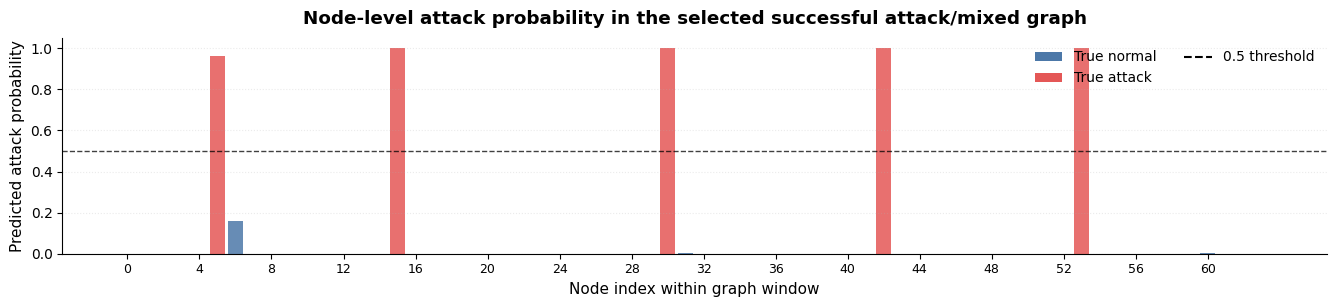

In [18]:

# ------------------------------------------------------------
# Figure A: ground-truth vs predicted node attack status
# ------------------------------------------------------------
plot_node_classification_timeline(
    node_cls_normal,
    title='(a) Normal graph: ground-truth vs predicted node status',
    save_path='../figures/explainability/node_classification_timeline_normal.pdf',
    figsize=(13.5, 2.8),
)

plot_node_classification_timeline(
    node_cls_attack,
    title='(b) Successful attack/mixed graph: ground-truth vs predicted node status',
    save_path='../figures/explainability/node_classification_timeline_successful_attack.pdf',
    figsize=(13.5, 2.8),
)

# ------------------------------------------------------------
# Figure B: node-level attack probability from the node head
# ------------------------------------------------------------
plot_node_attack_probability(
    node_cls_attack,
    title='Node-level attack probability in the selected successful attack/mixed graph',
    save_path='../figures/explainability/node_attack_probability_successful_attack_graph.pdf',
    figsize=(13.5, 3.2),
)



## Graph layout visualization for node classification

Bên cạnh timeline, cell dưới đây vẽ trực tiếp **graph layout** của một window được chọn. Mục tiêu là hiển thị node nào là normal/attack trên cấu trúc graph thực tế:

- panel bên trái: **ground-truth node status**;
- panel bên phải: **predicted node status**;
- màu node: normal hoặc attack;
- viền đậm/dấu khác biệt: node prediction không khớp với ground truth;
- cạnh có thể được tô theo `edge_type` để minh họa các quan hệ trong multi-relational graph.

Hình này phù hợp để bổ sung cho timeline, vì timeline cho thấy vị trí node theo thứ tự message, còn graph layout cho thấy node attack nằm trong cấu trúc kết nối của graph/window.


In [19]:

# ------------------------------------------------------------
# Graph layout visualization for node classification
# ------------------------------------------------------------
from typing import Dict, Any, Optional, Tuple
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt

try:
    import networkx as nx
except ImportError as e:
    raise ImportError(
        "networkx is required for graph layout visualization. "
        "Install it with: pip install networkx"
    ) from e


RELATION_TYPE_NAMES = {
    0: "Temporal",
    1: "Same-ID",
    2: "Payload-sim",
    3: "Timing-aff",
}

RELATION_TYPE_COLORS = {
    0: "#9E9E9E",
    1: "#59A14F",
    2: "#F28E2B",
    3: "#B07AA1",
}

NODE_NORMAL_COLOR = "#4C78A8"
NODE_ATTACK_COLOR = "#E45756"


def _get_edge_arrays_from_data(data: Data) -> Tuple[np.ndarray, np.ndarray]:
    """Return edge_index [2, E] and edge_type [E] from a PyG Data object."""
    edge_index = data.edge_index.detach().cpu().numpy()
    if hasattr(data, "edge_type"):
        edge_type = data.edge_type.detach().cpu().numpy()
    else:
        edge_type = np.zeros(edge_index.shape[1], dtype=int)
    return edge_index, edge_type


def _build_layout_graph(
    data: Data,
    node_mask: Optional[np.ndarray] = None,
    make_undirected: bool = True,
):
    """Build a NetworkX graph for layout computation."""
    num_nodes = int(data.x.size(0))
    if node_mask is None:
        valid_nodes = np.arange(num_nodes)
    else:
        valid_nodes = np.where(node_mask.astype(bool))[0]

    G = nx.Graph() if make_undirected else nx.DiGraph()
    G.add_nodes_from(valid_nodes.tolist())

    edge_index, _ = _get_edge_arrays_from_data(data)
    valid_set = set(valid_nodes.tolist())

    for u, v in edge_index.T:
        u, v = int(u), int(v)
        if u in valid_set and v in valid_set:
            G.add_edge(u, v)

    return G, valid_nodes


def _sample_edges_by_relation(
    edge_index: np.ndarray,
    edge_type: np.ndarray,
    valid_nodes: np.ndarray,
    max_edges_per_relation: Optional[int] = 350,
    seed: int = 42,
):
    """Group edges by relation type and optionally subsample for readable plots."""
    rng = np.random.default_rng(seed)
    valid_set = set(valid_nodes.tolist())
    rel_edges: Dict[int, list] = {}

    for k, (u, v) in enumerate(edge_index.T):
        u, v = int(u), int(v)
        if u not in valid_set or v not in valid_set:
            continue
        r = int(edge_type[k]) if k < len(edge_type) else 0
        rel_edges.setdefault(r, []).append((u, v))

    if max_edges_per_relation is not None:
        for r, edges in list(rel_edges.items()):
            if len(edges) > max_edges_per_relation:
                idx = rng.choice(len(edges), size=max_edges_per_relation, replace=False)
                rel_edges[r] = [edges[i] for i in idx]

    return rel_edges


def _draw_relation_edges(
    ax,
    G_layout,
    pos,
    data: Data,
    valid_nodes: np.ndarray,
    draw_relation_edges: bool = True,
    max_edges_per_relation: Optional[int] = 350,
    edge_alpha: float = 0.22,
):
    """Draw graph edges, optionally colored by relation type."""
    edge_index, edge_type = _get_edge_arrays_from_data(data)

    if draw_relation_edges:
        rel_edges = _sample_edges_by_relation(
            edge_index=edge_index,
            edge_type=edge_type,
            valid_nodes=valid_nodes,
            max_edges_per_relation=max_edges_per_relation,
        )
        for r, edges in sorted(rel_edges.items(), key=lambda kv: kv[0]):
            if not edges:
                continue
            nx.draw_networkx_edges(
                G_layout,
                pos,
                edgelist=edges,
                ax=ax,
                edge_color=RELATION_TYPE_COLORS.get(int(r), "#BDBDBD"),
                width=0.7,
                alpha=edge_alpha,
                arrows=False,
            )
    else:
        nx.draw_networkx_edges(
            G_layout,
            pos,
            ax=ax,
            edge_color="#BDBDBD",
            width=0.7,
            alpha=edge_alpha,
            arrows=False,
        )


def plot_graph_layout_node_classification(
    data: Data,
    result: Dict[str, Any],
    title: Optional[str] = None,
    save_path: Optional[str] = None,
    figsize=(14, 6.2),
    layout_seed: int = 42,
    draw_relation_edges: bool = True,
    max_edges_per_relation: Optional[int] = 350,
    show_labels_for_attack_and_error: bool = True,
):
    """
    Draw graph layout with two panels:
        left  = ground-truth normal/attack node status
        right = predicted normal/attack node status

    This complements the timeline plot by showing how detected attack nodes
    are located within the graph structure.
    """
    true_bin = result["true_is_attack"].detach().cpu().numpy().astype(int)
    pred_bin = result["pred_is_attack"].detach().cpu().numpy().astype(int)
    node_mask = result["node_mask"].detach().cpu().numpy().astype(bool)

    G_layout, valid_nodes = _build_layout_graph(data, node_mask=node_mask, make_undirected=True)

    if G_layout.number_of_nodes() == 0:
        raise RuntimeError("Cannot draw graph layout: no valid nodes found.")

    # Stable layout for both panels.
    # k is chosen to reduce overlap for 64-node windows.
    pos = nx.spring_layout(
        G_layout,
        seed=layout_seed,
        k=1.25 / np.sqrt(max(G_layout.number_of_nodes(), 1)),
        iterations=300,
    )

    plt.rcParams.update({
        "axes.labelsize": 11,
        "font.size": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    statuses = [true_bin, pred_bin]
    panel_titles = ["Ground truth node status", "Predicted node status"]
    mismatch = true_bin != pred_bin

    for ax, status, panel_title in zip(axes, statuses, panel_titles):
        _draw_relation_edges(
            ax=ax,
            G_layout=G_layout,
            pos=pos,
            data=data,
            valid_nodes=valid_nodes,
            draw_relation_edges=draw_relation_edges,
            max_edges_per_relation=max_edges_per_relation,
            edge_alpha=0.22,
        )

        node_colors = [NODE_ATTACK_COLOR if status[i] == 1 else NODE_NORMAL_COLOR for i in valid_nodes]
        node_edgecolors = ["black" if mismatch[i] else "white" for i in valid_nodes]
        node_linewidths = [1.8 if mismatch[i] else 0.55 for i in valid_nodes]

        nx.draw_networkx_nodes(
            G_layout,
            pos,
            nodelist=valid_nodes.tolist(),
            node_color=node_colors,
            edgecolors=node_edgecolors,
            linewidths=node_linewidths,
            node_size=115,
            ax=ax,
        )

        if show_labels_for_attack_and_error:
            label_nodes = [int(i) for i in valid_nodes if true_bin[i] == 1 or pred_bin[i] == 1 or mismatch[i]]
            labels = {i: str(i) for i in label_nodes}
            nx.draw_networkx_labels(
                G_layout,
                pos,
                labels=labels,
                font_size=7,
                font_color="black",
                ax=ax,
            )

        ax.set_title(panel_title, fontweight="bold")
        ax.set_axis_off()

    if title is None:
        title = (
            f"Graph layout: {result['graph_id']} | "
            f"true={result['graph_true_name']} | pred={result['graph_pred_name']} | "
            f"node acc={result['binary_attack_acc']:.3f}"
        )
    fig.suptitle(title, fontweight="bold", y=1.02)

    node_legend = [
        Patch(facecolor=NODE_NORMAL_COLOR, edgecolor="white", label="Normal node"),
        Patch(facecolor=NODE_ATTACK_COLOR, edgecolor="white", label="Attack node"),
        Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="white",
               markeredgecolor="black", markeredgewidth=1.8, label="Mismatch"),
    ]

    if draw_relation_edges:
        relation_legend = [
            Line2D([0], [0], color=RELATION_TYPE_COLORS.get(r, "#BDBDBD"), lw=2,
                   label=RELATION_TYPE_NAMES.get(r, f"Relation {r}"))
            for r in sorted(set(_get_edge_arrays_from_data(data)[1].tolist()))
            if r in RELATION_TYPE_NAMES
        ]
    else:
        relation_legend = [Line2D([0], [0], color="#BDBDBD", lw=2, label="Graph edge")]

    fig.legend(
        handles=node_legend + relation_legend,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=min(7, len(node_legend + relation_legend)),
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.98])

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight", format=save_path.split(".")[-1])
        print(f"[*] Saved graph layout visualization to: {save_path}")

    plt.show()
    plt.rcdefaults()


[*] Saved graph layout visualization to: ../figures/explainability/node_classification_graph_layout_successful_attack.pdf


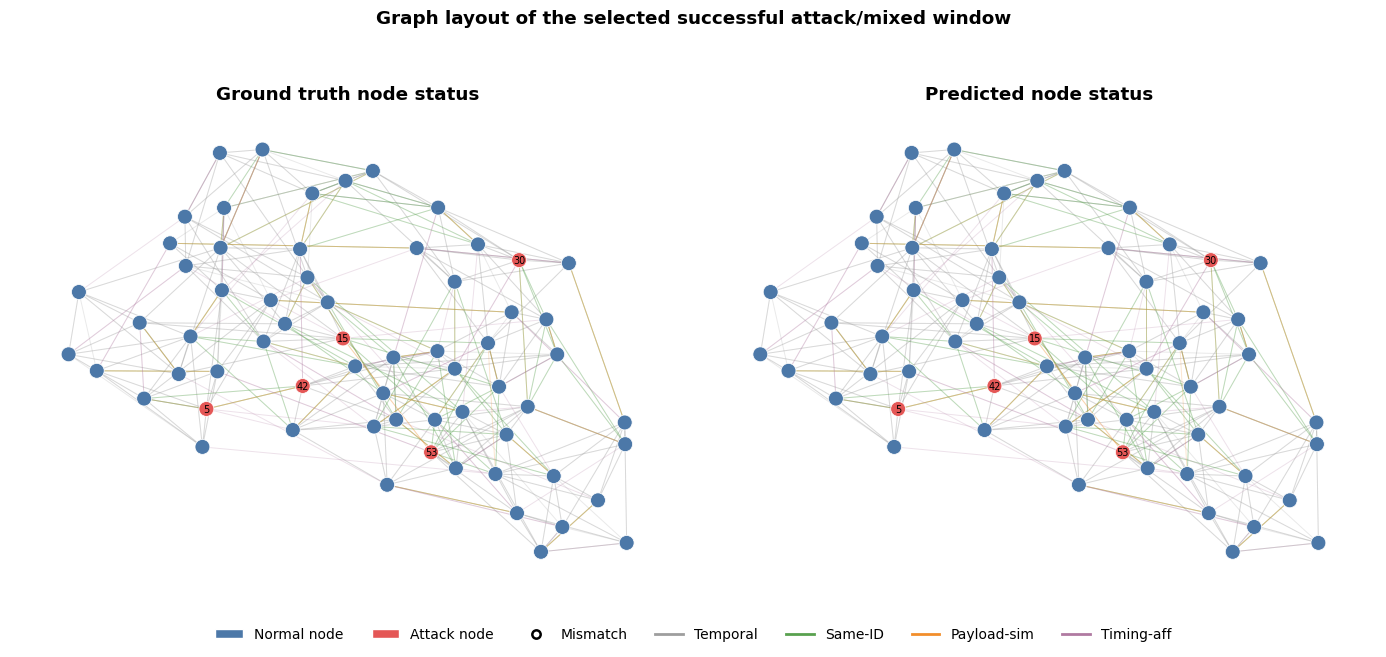

[*] Saved graph layout visualization to: ../figures/explainability/node_classification_graph_layout_normal.pdf


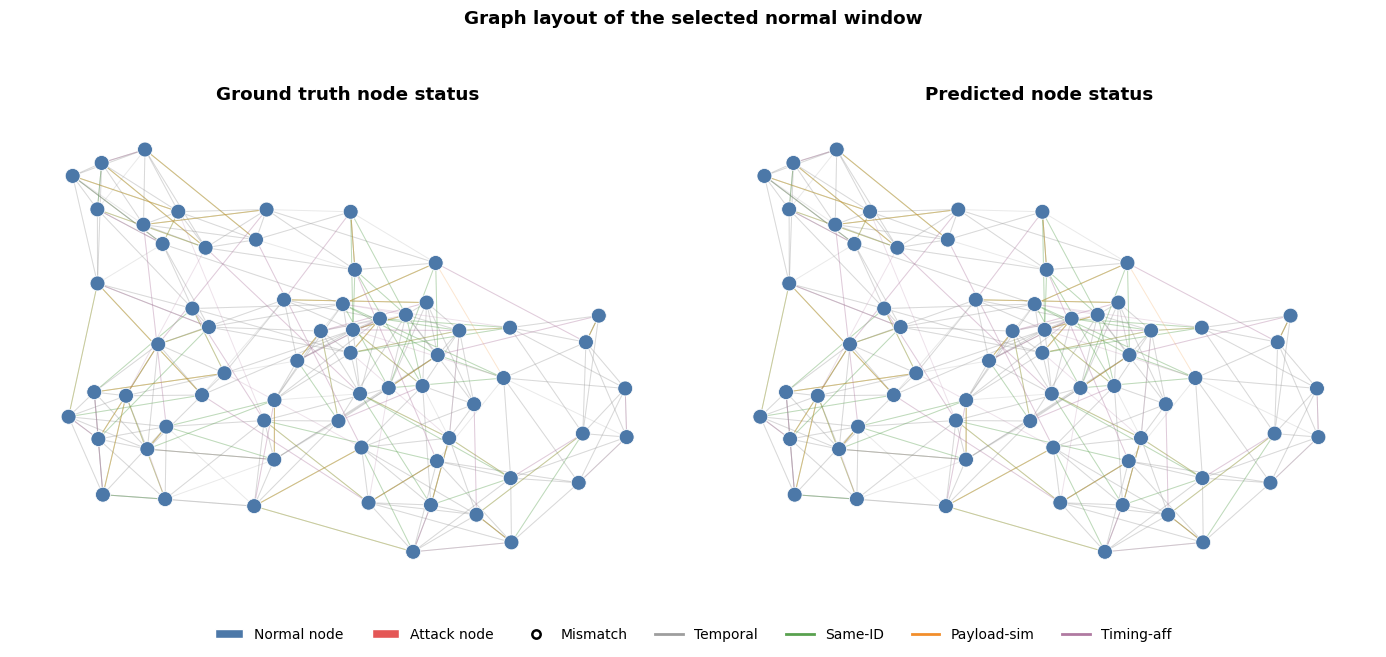

In [20]:

# ------------------------------------------------------------
# Figure C: graph layout visualization for the selected successful attack/mixed graph
# ------------------------------------------------------------
plot_graph_layout_node_classification(
    data=data_node_attack,
    result=node_cls_attack,
    title='Graph layout of the selected successful attack/mixed window',
    save_path='../figures/explainability/node_classification_graph_layout_successful_attack.pdf',
    figsize=(14, 6.2),
    layout_seed=42,
    draw_relation_edges=True,
    max_edges_per_relation=350,
    show_labels_for_attack_and_error=True,
)

# Optional: also save a normal-window graph layout for comparison.
plot_graph_layout_node_classification(
    data=data_normal,
    result=node_cls_normal,
    title='Graph layout of the selected normal window',
    save_path='../figures/explainability/node_classification_graph_layout_normal.pdf',
    figsize=(14, 6.2),
    layout_seed=42,
    draw_relation_edges=True,
    max_edges_per_relation=350,
    show_labels_for_attack_and_error=True,
)



**Cách diễn giải graph layout visualization**:

- Hai panel dùng cùng một layout, vì vậy có thể so sánh trực tiếp vị trí node giữa ground truth và prediction.
- Node màu xanh là normal, node màu đỏ là attack.
- Node có viền đậm màu đen là node dự đoán sai giữa trạng thái normal/attack.
- Các cạnh được tô theo `edge_type`, tương ứng với các relation trong graph như temporal, same-ID, payload-similarity và timing-affinity.
- Nếu các node attack trong panel prediction trùng với panel ground truth, điều này cho thấy node head không chỉ phân loại cả window đúng mà còn định vị được các message bất thường ở cấp node.



**Cách diễn giải hình node classification**:

- Nếu hàng **Prediction** khớp với hàng **Ground truth**, node head đang định vị đúng các message attack trong window.
- Trong biểu đồ probability, các cột đỏ là node attack thật. Nếu các cột đỏ có xác suất attack cao và các cột xanh có xác suất thấp, mô hình không chỉ phân loại graph đúng mà còn học được vị trí bất thường ở cấp message/node.
- Với Figure 2b, notebook tự động quét tập dữ liệu để chọn một mixed window có nhiều attack nodes hơn, ưu tiên true attack nodes >= 3, graph-level prediction đúng, attack recall = 1.0, attack precision = 1.0 và binary node accuracy gần 1.0. Nếu không tìm được strict-perfect case, notebook sẽ chọn mixed window fallback tốt nhất theo các tiêu chí trên.



# Phần 3 — Decision-level explanation bằng KAN head

**Mục tiêu**: KAN head biến graph embedding thành quyết định như thế nào?

Ta làm 3 bước:
1. chọn 1 graph để phân tích (`attack` hoặc `normal`)
2. lấy **graph embedding** sau GNN + pooling
3. dùng **gradient × input** để tìm **top-3 embedding dimensions** quan trọng nhất cho class được dự đoán
4. với mỗi dimension, giữ nguyên các dimension khác và chỉ thay đổi dimension đó → vẽ **KAN head response curve**

Hình duy nhất ở phần này là **3 panel response curves** cho top-3 dimensions.


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from typing import Dict, Any, Optional


def get_graph_embedding(model, data: Data, device: str = "cpu") -> torch.Tensor:
    """
    Returns graph embedding g with no grad, shape [1, D].
    """
    model.eval()
    data = data.to(device)

    with torch.no_grad():
        h = model.encode_nodes(data)
        batch = getattr(data, "batch", None)
        if batch is None:
            batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        g = model.readout(h, batch)

    return g.detach().cpu()


def get_graph_embedding_with_grad(model, data: Data, device: str = "cpu") -> torch.Tensor:
    """
    Returns graph embedding g with grad path preserved, shape [1, D].
    """
    model.eval()
    data = data.to(device)

    h = model.encode_nodes(data)
    batch = getattr(data, "batch", None)
    if batch is None:
        batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
    g = model.readout(h, batch)

    return g


def compute_kan_head_dim_importance(model, data: Data, device: str = "cpu"):
    """
    Importance of each graph-embedding dimension for the predicted class,
    using |grad * input| at the KAN head input.
    """
    model.eval()

    g = get_graph_embedding_with_grad(model, data, device=device)
    g = g.detach().clone().requires_grad_(True).to(device)

    logits = model.head(g)
    pred_idx = int(logits.argmax(dim=1).item())
    score = logits[0, pred_idx]

    grad = torch.autograd.grad(score, g, retain_graph=False, create_graph=False)[0]

    importance = (grad * g).abs().detach().cpu().numpy()[0]
    g_np = g.detach().cpu().numpy()[0]
    logits_np = logits.detach().cpu().numpy()[0]

    return {
        "pred_idx": pred_idx,
        "graph_embedding": g.detach().cpu(),   # [1, D]
        "importance": importance,              # [D]
        "grad": grad.detach().cpu().numpy()[0],
        "g_np": g_np,
        "logits_np": logits_np,
    }


def collect_embedding_background(
    model,
    graph_folder: Path,
    split: str,
    label_mapping: Dict[int, str],
    target_label_name: Optional[str] = None,
    max_samples: int = 80,
    device: str = "cpu",
):
    """
    Collect background graph embeddings for histogram plotting.
    If target_label_name is not None, only collect graphs of that label.
    """
    embs = []
    names = []

    for raw_g in iter_raw_graphs(graph_folder, split):
        label_name = get_graph_label_name(raw_g, label_mapping)

        if target_label_name is not None:
            if normalize_label_name(label_name) != normalize_label_name(target_label_name):
                continue

        data = graph_dict_to_data(raw_g)
        g = get_graph_embedding(model, data, device=device)   # [1, D]
        embs.append(g.numpy()[0])
        names.append(label_name)

        if len(embs) >= max_samples:
            break

    if len(embs) == 0:
        raise ValueError("No background embeddings collected.")

    return np.stack(embs, axis=0), names


def sweep_one_embedding_dim_through_head(
    model,
    base_g: torch.Tensor,
    dim_idx: int,
    x_grid_np: np.ndarray,
    device: str = "cpu",
):
    """
    Sweep one graph-embedding dimension while keeping all others fixed.
    Return logits for all classes: shape [N, num_classes]
    """
    model.eval()
    curves = []

    base_g = base_g.clone().detach().to(device)

    with torch.no_grad():
        for val in x_grid_np:
            g = base_g.clone()
            g[0, dim_idx] = float(val)
            logits = model.head(g)   # [1, C]
            curves.append(logits.detach().cpu().numpy()[0])

    return np.stack(curves, axis=0)  # [N, num_classes]


def plot_kan_head_top_dims(
    model,
    base_g: torch.Tensor,
    kan_info: Dict[str, Any],
    bg_embs: np.ndarray,
    label_mapping: Dict[int, str],
    device: str = "cpu",
    top_k: int = 3,
    figsize=(15, 4.5),
):
    """
    Plot top-k important graph-embedding dimensions for the predicted class.
    For each dimension:
      - class logit curve
      - vertical line at selected graph value
      - histogram of background embedding values
    """
    pred_idx = kan_info["pred_idx"]
    pred_name = label_mapping.get(pred_idx, f"class_{pred_idx}")
    importance = kan_info["importance"]

    top_dims = np.argsort(importance)[::-1][:top_k]

    fig, axes = plt.subplots(
        1, top_k,
        figsize=figsize,
        constrained_layout=True
    )
    if top_k == 1:
        axes = [axes]

    for ax, dim_idx in zip(axes, top_dims):
        vals = bg_embs[:, dim_idx]

        lo = np.quantile(vals, 0.01)
        hi = np.quantile(vals, 0.99)

        if hi <= lo:
            lo, hi = vals.min(), vals.max()
        if hi <= lo:
            hi = lo + 1e-3

        margin = max((hi - lo) * 0.08, 1e-3)
        x_grid = np.linspace(lo - margin, hi + margin, 240)

        curves = sweep_one_embedding_dim_through_head(
            model=model,
            base_g=base_g,
            dim_idx=int(dim_idx),
            x_grid_np=x_grid,
            device=device,
        )

        y_pred = curves[:, pred_idx]
        selected_val = float(base_g[0, dim_idx].item())

        ax.plot(x_grid, y_pred, lw=2.2, color="C0")
        ax.axvline(
            selected_val,
            color="crimson",
            linestyle="--",
            lw=1.6,
        )

        ax.set_title(f"dim {dim_idx} | importance={importance[dim_idx]:.4f}", fontsize=13)
        ax.set_xlabel("embedding value", fontsize=11)
        ax.set_ylabel("class logit", fontsize=11)
        ax.grid(True, alpha=0.25)

        ax2 = ax.twinx()
        ax2.hist(vals, bins=30, density=True, alpha=0.22, color="C0")
        ax2.set_ylabel("density", fontsize=10)

    handles = [
        Line2D([0], [0], color="C0", lw=2.2, label=f"logit({pred_name})"),
        Line2D([0], [0], color="crimson", lw=1.6, linestyle="--", label="selected graph"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"KAN head decision curves | predicted class = {pred_name}", fontsize=18, y=1.08)

    plt.show()

    return top_dims, pred_name

KAN analysis graph: interval__00052416_00052480
true label = interval
pred label = interval
background embeddings shape = (80, 256)


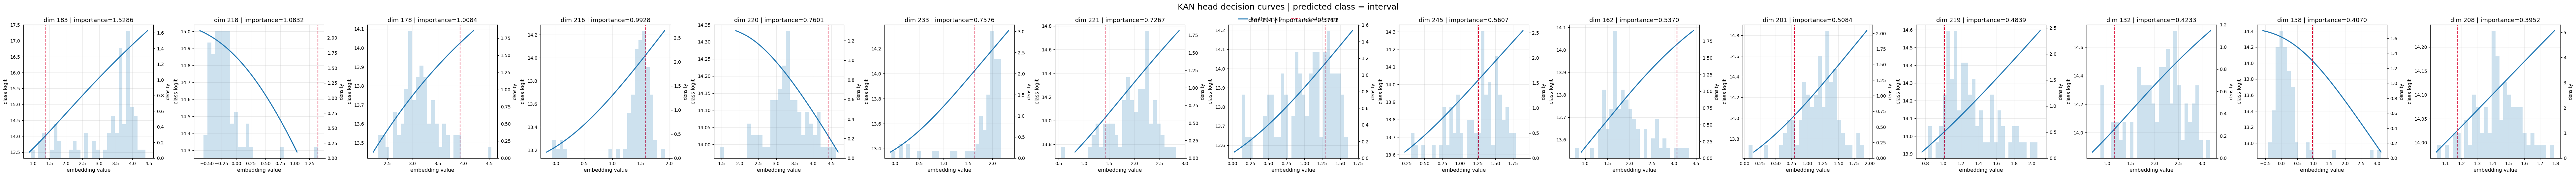

Top KAN dims = [183, 218, 178, 216, 220, 233, 221, 194, 245, 162, 201, 219, 132, 158, 208]


In [ ]:
# Chọn graph để phân tích KAN head
analysis_raw = raw_attack if KAN_ANALYSIS_GRAPH == "attack" else raw_normal
analysis_data = data_attack if KAN_ANALYSIS_GRAPH == "attack" else data_normal
analysis_label_name = attack_label_name if KAN_ANALYSIS_GRAPH == "attack" else normal_label_name

# Tính importance ở input của KAN head
kan_info = compute_kan_head_dim_importance(
    model,
    analysis_data,
    device=DEVICE,
)

analysis_pred_name = ckpt_label_mapping.get(
    kan_info["pred_idx"],
    f'class_{kan_info["pred_idx"]}'
)

# Graph embedding của graph đang phân tích
base_g = get_graph_embedding(
    model,
    analysis_data,
    device=DEVICE,
)

# Background embeddings để vẽ histogram
bg_label = analysis_label_name if KAN_BG_SAME_LABEL_ONLY else None

bg_embs, bg_names = collect_embedding_background(
    model=model,
    graph_folder=GRAPH_FOLDER,
    split=SPLIT,
    label_mapping=ckpt_label_mapping,
    target_label_name=bg_label,
    max_samples=KAN_BG_MAX_SAMPLES,
    device=DEVICE,
)

print("KAN analysis graph:", analysis_data.graph_id)
print("true label =", analysis_label_name)
print("pred label =", analysis_pred_name)
print("background embeddings shape =", bg_embs.shape)

top_dims, pred_name = plot_kan_head_top_dims(
    model=model,
    base_g=base_g,
    kan_info=kan_info,
    bg_embs=bg_embs,
    label_mapping=ckpt_label_mapping,
    device=DEVICE,
    top_k=TOP_K_KAN_DIMS,
    figsize=(5.2 * TOP_K_KAN_DIMS, 4.8),
)

print("Top KAN dims =", top_dims.tolist())

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
from typing import Dict, Any, Optional
import os

# --- CÁC HÀM TÍNH TOÁN (Giữ nguyên logic chuẩn của bạn) ---

def get_graph_embedding(model, data, device: str = "cpu") -> torch.Tensor:
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        h = model.encode_nodes(data)
        batch = getattr(data, "batch", None)
        if batch is None:
            batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        g = model.readout(h, batch)
    return g.detach().cpu()

def get_graph_embedding_with_grad(model, data, device: str = "cpu") -> torch.Tensor:
    model.eval()
    data = data.to(device)
    h = model.encode_nodes(data)
    batch = getattr(data, "batch", None)
    if batch is None:
        batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
    g = model.readout(h, batch)
    return g

def compute_kan_head_dim_importance(model, data, device: str = "cpu"):
    model.eval()
    g = get_graph_embedding_with_grad(model, data, device=device)
    g = g.detach().clone().requires_grad_(True).to(device)

    logits = model.head(g)
    pred_idx = int(logits.argmax(dim=1).item())
    score = logits[0, pred_idx]

    grad = torch.autograd.grad(score, g, retain_graph=False, create_graph=False)[0]

    signed_effect = (grad * g).detach().cpu().numpy()[0]
    importance = np.abs(signed_effect)

    return {
        "pred_idx": pred_idx,
        "graph_embedding": g.detach().cpu(),   
        "importance": importance,              
        "signed_effect": signed_effect,        
        "grad": grad.detach().cpu().numpy()[0],
        "g_np": g.detach().cpu().numpy()[0],
        "logits_np": logits.detach().cpu().numpy()[0],
    }

def collect_embedding_background(
    model, graph_folder: Path, split: str, label_mapping: Dict[int, str],
    target_label_name: Optional[str] = None, max_samples: int = 80, device: str = "cpu"
):
    embs = []
    names = []
    # Giả định các hàm iter_raw_graphs, get_graph_label_name, normalize_label_name, graph_dict_to_data đã có
    for raw_g in iter_raw_graphs(graph_folder, split):
        label_name = get_graph_label_name(raw_g, label_mapping)
        if target_label_name is not None:
            if normalize_label_name(label_name) != normalize_label_name(target_label_name):
                continue
        data = graph_dict_to_data(raw_g)
        g = get_graph_embedding(model, data, device=device)
        embs.append(g.numpy()[0])
        names.append(label_name)
        if len(embs) >= max_samples:
            break

    if len(embs) == 0:
        raise ValueError("No background embeddings collected.")
    return np.stack(embs, axis=0), names

def sweep_one_embedding_dim_through_head(
    model, base_g: torch.Tensor, dim_idx: int, x_grid_np: np.ndarray, device: str = "cpu"
):
    model.eval()
    curves = []
    base_g = base_g.clone().detach().to(device)
    with torch.no_grad():
        for val in x_grid_np:
            g = base_g.clone()
            g[0, dim_idx] = float(val)
            logits = model.head(g)
            curves.append(logits.detach().cpu().numpy()[0])
    return np.stack(curves, axis=0)

def select_meaningful_dims(kan_info: Dict[str, Any], top_k: int = 3):
    signed_effect = np.asarray(kan_info["signed_effect"])
    importance = np.asarray(kan_info["importance"])
    used = []
    labels = []

    pos_idx = np.where(signed_effect > 0)[0]
    neg_idx = np.where(signed_effect < 0)[0]

    if len(pos_idx) > 0:
        i_pos = pos_idx[np.argmax(signed_effect[pos_idx])]
        used.append(int(i_pos))
        labels.append("Positive") # Đổi sang viết hoa cho đẹp
    if len(neg_idx) > 0:
        i_neg = neg_idx[np.argmin(signed_effect[neg_idx])]
        if int(i_neg) not in used:
            used.append(int(i_neg))
            labels.append("Negative")

    remaining = [i for i in np.argsort(importance)[::-1] if int(i) not in used]
    while len(used) < top_k and len(remaining) > 0:
        used.append(int(remaining.pop(0)))
        labels.append("Remaining")

    return np.array(used[:top_k], dtype=int), labels[:top_k]

# --- HÀM VẼ ĐỒ THỊ MỚI (Chuẩn học thuật) ---

def plot_kan_head_meaningful_dims(
    model, base_g: torch.Tensor, kan_info: Dict[str, Any], bg_embs: np.ndarray,
    label_mapping: Dict[int, str], device: str = "cpu", top_k: int = 3,
    figsize=(14, 4.5), save_path: Optional[str] = None
):
    # 1. Cấu hình Font chuẩn học thuật
    plt.rcParams.update({
        "axes.labelsize": 11,
        "font.size": 11,
        "legend.fontsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.titlesize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

    pred_idx = kan_info["pred_idx"]
    pred_name = label_mapping.get(pred_idx, f"class_{pred_idx}")
    importance = np.asarray(kan_info["importance"])
    signed_effect = np.asarray(kan_info["signed_effect"])

    top_dims, dim_roles = select_meaningful_dims(kan_info, top_k=top_k)

    fig, axes = plt.subplots(1, len(top_dims), figsize=figsize)
    if len(top_dims) == 1:
        axes = [axes]

    for ax, dim_idx, role in zip(axes, top_dims, dim_roles):
        vals = bg_embs[:, dim_idx]

        lo = np.quantile(vals, 0.01)
        hi = np.quantile(vals, 0.99)
        if hi <= lo:
            lo, hi = vals.min(), vals.max()
        if hi <= lo:
            hi = lo + 1e-3

        margin = max((hi - lo) * 0.08, 1e-3)
        x_grid = np.linspace(lo - margin, hi + margin, 240)

        curves = sweep_one_embedding_dim_through_head(
            model=model, base_g=base_g, dim_idx=int(dim_idx), x_grid_np=x_grid, device=device,
        )
        y_pred = curves[:, pred_idx]
        selected_val = float(base_g[0, dim_idx].item())

        # Vẽ đường cong KAN và giá trị mẫu hiện tại
        ax.plot(x_grid, y_pred, lw=2.5, color="#1f77b4", zorder=3)
        ax.axvline(selected_val, color="#d62728", linestyle="--", lw=1.8, zorder=4)

        # Trục phụ cho mật độ phân bố (Histogram)
        ax2 = ax.twinx()
        ax2.hist(vals, bins=30, density=True, color="lightgray", alpha=0.7, zorder=1)
        ax2.set_ylabel("Data Density", color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

        # Định dạng tiêu đề và trục gọn gàng, học thuật hơn
        sign_txt = "+" if signed_effect[dim_idx] > 0 else "-"
        ax.set_title(
            f"Dimension {dim_idx}\n(Role: {role} [{sign_txt}], |Effect|: {importance[dim_idx]:.3f})",
            fontweight='bold', pad=10
        )
        ax.set_xlabel("Embedding Value", fontweight='bold')
        ax.set_ylabel("Class Logit", color="#1f77b4", fontweight='bold')
        ax.tick_params(axis='y', labelcolor="#1f77b4")
        ax.grid(True, alpha=0.3, linestyle="--")

    # 2. Tạo Legend tổng hợp đặt dưới cùng (không đè lên đồ thị)
    handles = [
        Line2D([0], [0], color="#1f77b4", lw=2.5, label=f"KAN Function $\phi(x)$"),
        Line2D([0], [0], color="#d62728", lw=1.8, linestyle="--", label="Current Instance"),
        Patch(facecolor='lightgray', edgecolor='none', alpha=0.7, label="Data Distribution")
    ]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False)

    plt.tight_layout()
    
    # 3. Lưu ảnh PDF chất lượng cao
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format=save_path.split('.')[-1])
        print(f"[*] Saved high-res meaningful KAN curves to: {save_path}")

    plt.show()
    plt.rcdefaults()

    return top_dims, dim_roles, pred_name

KAN analysis graph: interval__00052416_00052480
true label = interval
pred label = interval
background embeddings shape = (80, 256)
[*] Saved high-res meaningful KAN curves to: ../figures/explainability/meaningful_kan_curves.pdf


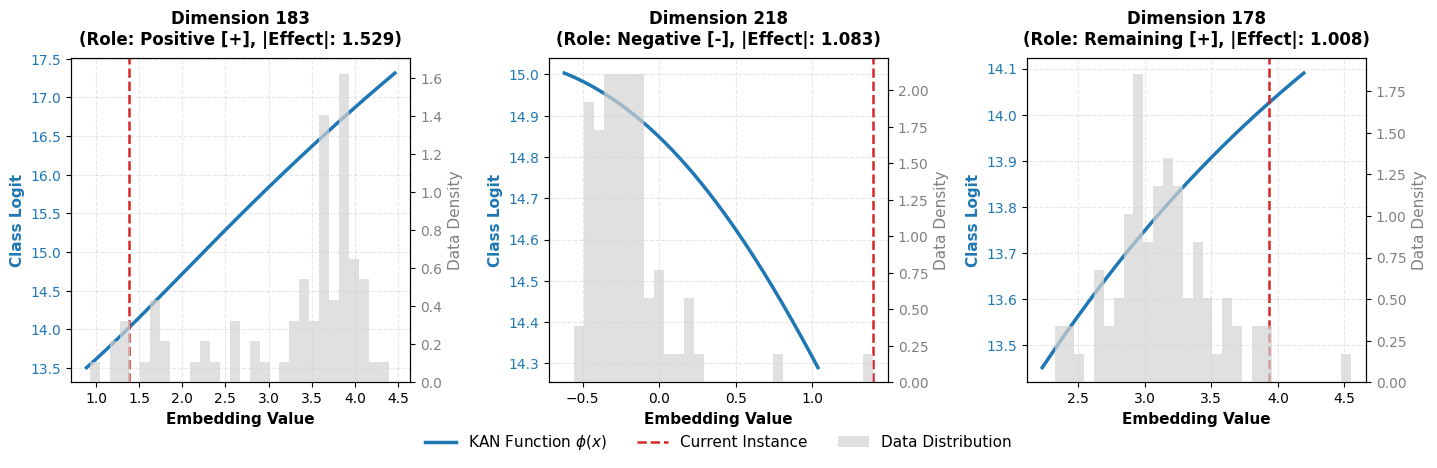


--- Summary ---
Selected dims = [183, 218, 178]
Roles = ['Positive', 'Negative', 'Remaining']


In [ ]:
analysis_raw = raw_attack if KAN_ANALYSIS_GRAPH == "attack" else raw_normal
analysis_data = data_attack if KAN_ANALYSIS_GRAPH == "attack" else data_normal
analysis_label_name = attack_label_name if KAN_ANALYSIS_GRAPH == "attack" else normal_label_name

kan_info = compute_kan_head_dim_importance(
    model,
    analysis_data,
    device=DEVICE,
)

analysis_pred_name = ckpt_label_mapping.get(
    kan_info["pred_idx"],
    f'class_{kan_info["pred_idx"]}'
)

base_g = get_graph_embedding(
    model,
    analysis_data,
    device=DEVICE,
)

bg_label = analysis_label_name if KAN_BG_SAME_LABEL_ONLY else None

bg_embs, bg_names = collect_embedding_background(
    model=model,
    graph_folder=GRAPH_FOLDER,
    split=SPLIT,
    label_mapping=ckpt_label_mapping,
    target_label_name=bg_label,
    max_samples=KAN_BG_MAX_SAMPLES,
    device=DEVICE,
)

print("KAN analysis graph:", analysis_data.graph_id)
print("true label =", analysis_label_name)
print("pred label =", analysis_pred_name)
print("background embeddings shape =", bg_embs.shape)

# Vẽ đồ thị sử dụng cấu hình mới
top_dims, dim_roles, pred_name = plot_kan_head_meaningful_dims(
    model=model,
    base_g=base_g,
    kan_info=kan_info,
    bg_embs=bg_embs,
    label_mapping=ckpt_label_mapping,
    device=DEVICE,
    top_k=3,
    figsize=(14.5, 4.5),
    save_path="../figures/explainability/meaningful_kan_curves.pdf"
)

print("\n--- Summary ---")
print("Selected dims =", top_dims.tolist())
print("Roles =", dim_roles)


## Gợi ý diễn giải ngắn gọn cho 3 hình

### Hình 1 — Relation heatmap
- ô nào dương lớn hơn nghĩa là **bỏ relation đó đi thì score class đúng giảm mạnh hơn**
- relation nào sáng mạnh hơn ở một class cho thấy mô hình đang **dựa vào relation đó** nhiều hơn cho class đó

### Hình 2 — Node/Subgraph case study
- node màu đậm hơn nghĩa là **che node đó đi thì score class đích giảm mạnh hơn**
- nếu graph attack tập trung mạnh vào một cụm node hơn normal, đó là bằng chứng mô hình đang dùng **subgraph cục bộ** để phát hiện bất thường

### Hình 2b — Node classification trong từng graph/window
- hàng Ground truth và Prediction cho biết node nào là normal/attack ở cấp message
- nếu hai hàng khớp nhau, node head định vị đúng các message tấn công trong window
- attack probability giúp kiểm tra mức độ tự tin của node head trên từng node

### Hình 3 — KAN head decision curves
- mỗi panel cho biết **một embedding dimension quan trọng** tác động thế nào lên logit class được dự đoán
- đường cong phi tuyến cho thấy KAN head không chỉ cộng tuyến tính, mà có thể học **ngưỡng / bão hòa / vùng khuếch đại / vùng ức chế**
